# **Open Data II: Machine Learning**- Supervisado

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Dataset_OData_Final_Martin_Otero.csv")

In [2]:
pd.options.display.max_columns = None
print(df.columns.to_list())

['FlightDate', 'sched_dep_dt', 'sched_arr_dt', 'dep_dt', 'arr_dt', 'Airline', 'Origin', 'Dest', 'DepDelayMinutes', 'DepDelay', 'ArrDelayMinutes', 'TotalDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'ArrDelay', 'ArrDel15', 'ArrivalDelayGroups', 'ArrTimeBlk', 'DistanceGroup', 'DivAirportLandings', 'o

In [3]:
df.head(5)


,FlightDate,sched_dep_dt,sched_arr_dt,dep_dt,arr_dt,Airline,Origin,Dest,DepDelayMinutes,DepDelay,ArrDelayMinutes,TotalDelayMinutes,AirTime,CRSElapsedTime,ActualElapsedTime,Distance,Marketing_Airline_Network,Operated_or_Branded_Code_Share_Partners,DOT_ID_Marketing_Airline,IATA_Code_Marketing_Airline,Flight_Number_Marketing_Airline,Operating_Airline,DOT_ID_Operating_Airline,IATA_Code_Operating_Airline,Tail_Number,Flight_Number_Operating_Airline,OriginAirportID,OriginAirportSeqID,OriginCityMarketID,OriginCityName,OriginState,OriginStateFips,OriginStateName,OriginWac,DestAirportID,DestAirportSeqID,DestCityMarketID,DestCityName,DestState,DestStateFips,DestStateName,DestWac,DepDel15,DepartureDelayGroups,DepTimeBlk,TaxiOut,WheelsOff,WheelsOn,TaxiIn,ArrDelay,ArrDel15,ArrivalDelayGroups,ArrTimeBlk,DistanceGroup,DivAirportLandings,origin_lat,origin_lon,dest_lat,dest_lon,aircraft_age,MODEL,TotalDelayMinutes.1
0,2021-03-03,2021-03-03 07:24:00,2021-03-03 08:43:00,2021-03-03 07:14:00,2021-03-03 08:18:00,SkyWest Airlines Inc.,SGU,PHX,0.0,-10.0,0.0,0.0,49.0,79.0,64.0,262.0,AA,AA_CODESHARE,19805,AA,3133,SkyWest Airlines Inc.,20304,OO,N728SK,3133,14794,1479405,34794,"St. George, UT",UT,49,Utah,87,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,0.0,-1.0,0700-0759,10.0,724.0,813.0,5.0,-25.0,0.0,-2.0,0800-0859,2,0.0,37.036389,-113.510306,33.435302,-112.005905,16.0,CL-600-2C10,0.0
1,2021-03-03,2021-03-03 09:22:00,2021-03-03 10:40:00,2021-03-03 09:17:00,2021-03-03 10:31:00,SkyWest Airlines Inc.,PHX,SGU,0.0,-5.0,0.0,0.0,48.0,78.0,74.0,262.0,AA,AA_CODESHARE,19805,AA,3134,SkyWest Airlines Inc.,20304,OO,N752SK,3134,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,14794,1479405,34794,"St. George, UT",UT,49,Utah,87,0.0,-1.0,0900-0959,23.0,940.0,1028.0,3.0,-9.0,0.0,-1.0,1000-1059,2,0.0,33.435302,-112.005905,37.036389,-113.510306,16.0,CL-600-2C10,0.0
2,2021-03-03,2021-03-03 13:30:00,2021-03-03 15:30:00,2021-03-03 13:21:00,2021-03-03 15:01:00,SkyWest Airlines Inc.,MHT,ORD,0.0,-9.0,0.0,0.0,129.0,180.0,160.0,843.0,AA,AA_CODESHARE,19805,AA,3135,SkyWest Airlines Inc.,20304,OO,N766SK,3135,13296,1329604,30721,"Manchester, NH",NH,33,New Hampshire,14,13930,1393007,30977,"Chicago, IL",IL,17,Illinois,41,0.0,-1.0,1300-1359,15.0,1336.0,1445.0,16.0,-29.0,0.0,-2.0,1500-1559,4,0.0,42.932598,-71.435699,41.978600,-87.904800,16.0,CL-600-2C10,0.0
3,2021-03-03,2021-03-03 16:45:00,2021-03-03 20:10:00,2021-03-03 16:36:00,2021-03-03 20:02:00,SkyWest Airlines Inc.,DFW,TRI,0.0,-9.0,0.0,0.0,112.0,145.0,146.0,868.0,AA,AA_CODESHARE,19805,AA,3136,SkyWest Airlines Inc.,20304,OO,N752EV,3136,11298,1129806,30194,"Dallas/Fort Worth, TX",TX,48,Texas,74,15323,1532305,35323,"Bristol/Johnson City/Kingsport, TN",TN,47,Tennessee,54,0.0,-1.0,1600-1659,27.0,1703.0,1955.0,7.0,-8.0,0.0,-1.0,2000-2059,4,0.0,32.896801,-97.038002,36.475201,-82.407401,NaN,CL-600-2C10,0.0
4,2021-03-03,2021-03-03 18:44:00,2021-03-03 19:25:00,2021-03-03 18:38:00,2021-03-03 19:03:00,SkyWest Airlines Inc.,PHX,BFL,0.0,-6.0,0.0,0.0,69.0,101.0,85.0,425.0,AA,AA_CODESHARE,19805,AA,3137,SkyWest Airlines Inc.,20304,OO,N715SK,3137,14107,1410702,30466,"Phoenix, AZ",AZ,4,Arizona,81,10561,1056103,30561,"Bakersfield, CA",CA,6,California,91,0.0,-1.0,1800-1859,13.0,1851.0,1900.0,3.0,-22.0,0.0,-2.0,1900-1959,2,0.0,33.435302,-112.005905,35.433601,-119.056999,17.0,CL-600-2C10,0.0


In [4]:
print(df.shape)
for i in df.columns:
    print(i, df[i].nunique())

(6107533, 62)
FlightDate 365
sched_dep_dt 393425
sched_arr_dt 429035
dep_dt 433241
arr_dt 451598
Airline 22
Origin 372
Dest 372
DepDelayMinutes 1597
DepDelay 1659
ArrDelayMinutes 1597
TotalDelayMinutes 2886
AirTime 670
CRSElapsedTime 589
ActualElapsedTime 697
Distance 1573
Marketing_Airline_Network 10
Operated_or_Branded_Code_Share_Partners 15
DOT_ID_Marketing_Airline 10
IATA_Code_Marketing_Airline 10
Flight_Number_Marketing_Airline 7000
Operating_Airline 22
DOT_ID_Operating_Airline 22
IATA_Code_Operating_Airline 21
Tail_Number 5752
Flight_Number_Operating_Airline 7000
OriginAirportID 372
OriginAirportSeqID 372
OriginCityMarketID 348
OriginCityName 366
OriginState 50
OriginStateFips 50
OriginStateName 50
OriginWac 50
DestAirportID 372
DestAirportSeqID 372
DestCityMarketID 348
DestCityName 366
DestState 50
DestStateFips 50
DestStateName 50
DestWac 50
DepDel15 2
DepartureDelayGroups 15
DepTimeBlk 19
TaxiOut 182
WheelsOff 1440
WheelsOn 1440
TaxiIn 208
ArrDelay 1687
ArrDel15 2
ArrivalDelay

# **Clasificacion Binaria:** Arrival delay >15

- Regresion Logistica
- Arbol
- Random Forest
- XGBoost

In [36]:
from sklearn.model_selection import train_test_split
import pandas as pd
from category_encoders import LeaveOneOutEncoder

# --- 1. CONFIGURACIÓN DEL SPLIT ---
target_bin = 'ArrDel15'

# Solo mantengo en cols_to_drop lo que es leakage puro de llegada o redundante
cols_to_drop_initial = [
    target_bin, 'TotalDelayMinutes', 'TotalDelayMinutes.1', 'ArrDelay', 
    'ArrDelayMinutes', 'TaxiIn', 'WheelsOn', 'ActualElapsedTime', 
    'ArrivalDelayGroups', 'DepartureDelayGroups', 'DivAirportLandings',
    'DepDel15', "AirTime"]

X_bin = df.drop(columns=[c for c in cols_to_drop_initial if c in df.columns])
y_bin = df[target_bin]

# Mantengo el split al 5% para test por el volumen de datos (6M)
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_bin, y_bin, test_size=0.05, random_state=42, stratify=y_bin
)

print(f"Split para llegada completado. Target: {target_bin}")


Split para llegada completado. Target: ArrDel15


In [37]:
# --- 2. EXTRACCIÓN DE VARIABLES TEMPORALES ---
def extract_time_features(df):
    df = df.copy()
    df['sched_dep_dt'] = pd.to_datetime(df['sched_dep_dt'])
    df['sched_month'] = df['sched_dep_dt'].dt.month
    df['sched_dayofweek'] = df['sched_dep_dt'].dt.dayofweek
    df['hour'] = df['sched_dep_dt'].dt.hour
    df['is_late_night'] = (df['hour'] >= 18).astype(int)
    return df

X_train_bin = extract_time_features(X_train_bin)
X_test_bin = extract_time_features(X_test_bin)

# --- 3. SELECCIÓN Y LIMPIEZA FINAL ---
target_encode_cols = [
    'Airline', 'Origin', 'Dest', 'MODEL', 
    'Marketing_Airline_Network', 'Operating_Airline',
    'OriginStateName', 'DestStateName'
]

# He añadido las coordenadas y textos residuales a la limpieza final
cols_to_drop_final = [
    'FlightDate', 'sched_dep_dt', 'sched_arr_dt', 'dep_dt', 'arr_dt', 
    'Tail_Number', 'Flight_Number_Marketing_Airline', 'Flight_Number_Operating_Airline', 
    'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginState', 'OriginStateFips', 'OriginWac',
    'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestState', 'DestStateFips', 'DestWac',
    'OriginCityName', 'DestCityName', 'DepTimeBlk', 'ArrTimeBlk',
    'origin_lat', 'origin_lon', 'dest_lat', 'dest_lon',
    'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 
    'IATA_Code_Marketing_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline'
]

X_train_bin = X_train_bin.drop(columns=[c for c in cols_to_drop_final if c in X_train_bin.columns])
X_test_bin = X_test_bin.drop(columns=[c for c in cols_to_drop_final if c in X_test_bin.columns])

# --- 4. LEAVE-ONE-OUT ENCODING ---
# Ajusto el encoder sobre el target de llegada
loo_encoder = LeaveOneOutEncoder(cols=target_encode_cols)

print("Iniciando codificación para el modelo de llegada...")
X_train_encoded = loo_encoder.fit_transform(X_train_bin, y_train_bin)
X_test_encoded = loo_encoder.transform(X_test_bin)

print("Codificación finalizada.")
print(f"Variables listas para el modelo: {X_train_encoded.columns.tolist()}")

Iniciando codificación para el modelo de llegada...
Codificación finalizada.
Variables listas para el modelo: ['Airline', 'Origin', 'Dest', 'DepDelayMinutes', 'DepDelay', 'CRSElapsedTime', 'Distance', 'Marketing_Airline_Network', 'Operating_Airline', 'OriginStateName', 'DestStateName', 'TaxiOut', 'WheelsOff', 'DistanceGroup', 'aircraft_age', 'MODEL', 'sched_month', 'sched_dayofweek', 'hour', 'is_late_night']


In [38]:
X_train_encoded.head()

,Airline,Origin,Dest,DepDelayMinutes,DepDelay,CRSElapsedTime,Distance,Marketing_Airline_Network,Operating_Airline,OriginStateName,DestStateName,TaxiOut,WheelsOff,DistanceGroup,aircraft_age,MODEL,sched_month,sched_dayofweek,hour,is_late_night
5044668,0.174244,0.205232,0.178607,124.0,124.0,148.0,925.0,0.165422,0.174244,0.210259,0.116220,15.0,2119.0,4,8.0,0.203236,10,4,19,1
4516872,0.139547,0.134158,0.185674,0.0,0.0,112.0,427.0,0.111048,0.139547,0.145172,0.173206,13.0,713.0,2,13.0,0.145945,5,6,7,0
1546934,0.115523,0.231170,0.112877,1.0,1.0,112.0,577.0,0.111048,0.115523,0.229424,0.116223,9.0,1010.0,3,3.0,0.116890,11,0,10,0
5987740,0.158082,0.115223,0.116157,0.0,-4.0,78.0,284.0,0.111048,0.158082,0.162598,0.116494,9.0,1327.0,2,0.0,0.126577,6,3,13,0
2001324,0.173366,0.160256,0.155629,0.0,-19.0,69.0,262.0,0.181702,0.173366,0.157293,0.171426,13.0,1413.0,2,20.0,0.175572,11,3,14,0


## Regresion Logistica

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
[CV] END ....................................logreg__C=0.001; total time=  23.0s
[CV] END ....................................logreg__C=0.001; total time=  20.7s
[CV] END ....................................logreg__C=0.001; total time=  19.3s
[CV] END .....................................logreg__C=0.01; total time=  20.0s
[CV] END .....................................logreg__C=0.01; total time=  20.2s
[CV] END .....................................logreg__C=0.01; total time=  20.0s
[CV] END ......................................logreg__C=0.1; total time=  20.5s
[CV] END ......................................logreg__C=0.1; total time=  19.5s
[CV] END ......................................logreg__C=0.1; total time=  19.8s
[CV] END ........................................logreg__C=1; total time=  20.1s
[CV] END ........................................logreg__C=1; total time=  19.6s
[CV] END

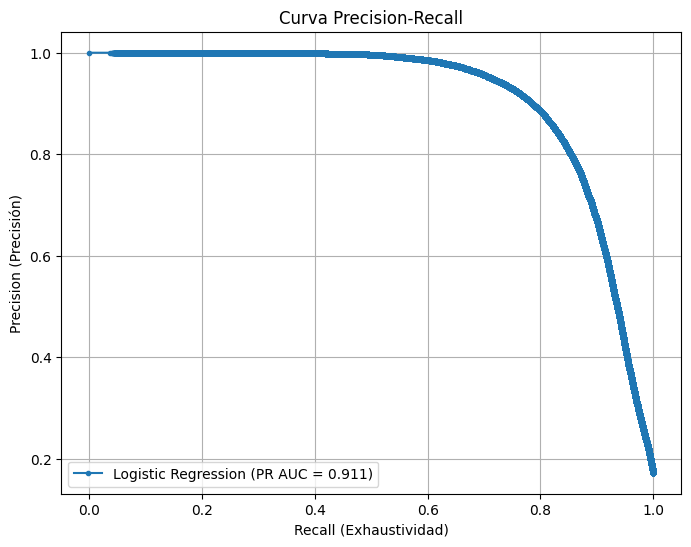

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Defino mi Pipeline (Imputacion -> Escalado -> Modelo)
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Cubre el NaN de aircraft_age
    ('scaler', StandardScaler()),                  # Vital para la regresión logística
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# 2. Espacio de búsqueda de hiperparámetros (Regularización C)
# Valores pequeños = mucha regularización (modelo más simple), Valores grandes = menos regularización
param_grid = {
    'logreg__C': [0.001, 0.01, 0.1, 1, 10]
}

# 3. Configuro GridSearchCV priorizando el PR AUC (average_precision)
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3,                      # 3-fold cross validation para no tardar una eternidad con 6M de filas
    scoring='average_precision', # Optimizamos específicamente para la curva PR
    verbose=2, 
    n_jobs=1                  
)

# 4. Entreno el modelo (¡Esto llevará un rato con tus datos!)
print("Iniciando búsqueda de hiperparámetros...")
grid_search.fit(X_train_encoded, y_train_bin)

# 5. Extraigo mi mejor modelo
best_model = grid_search.best_estimator_
print(f"Mejor parámetro C encontrado: {grid_search.best_params_['logreg__C']}")

# 6. Predicciones y Probabilidades sobre el set de prueba
y_pred = best_model.predict(X_test_encoded)
y_probs = best_model.predict_proba(X_test_encoded)[:, 1] # Probabilidad de la clase 1 (Retraso)

# 7. Reporte de Métricas Clásicas
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test_bin, y_pred))

# 8. Gráfica de la Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test_bin, y_probs)
pr_auc = average_precision_score(y_test_bin, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'Logistic Regression (PR AUC = {pr_auc:.3f})')
plt.xlabel('Recall (Exhaustividad)')
plt.ylabel('Precision (Precisión)')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_6560\1879755688.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Coeficiente', y='Variable', palette='viridis')


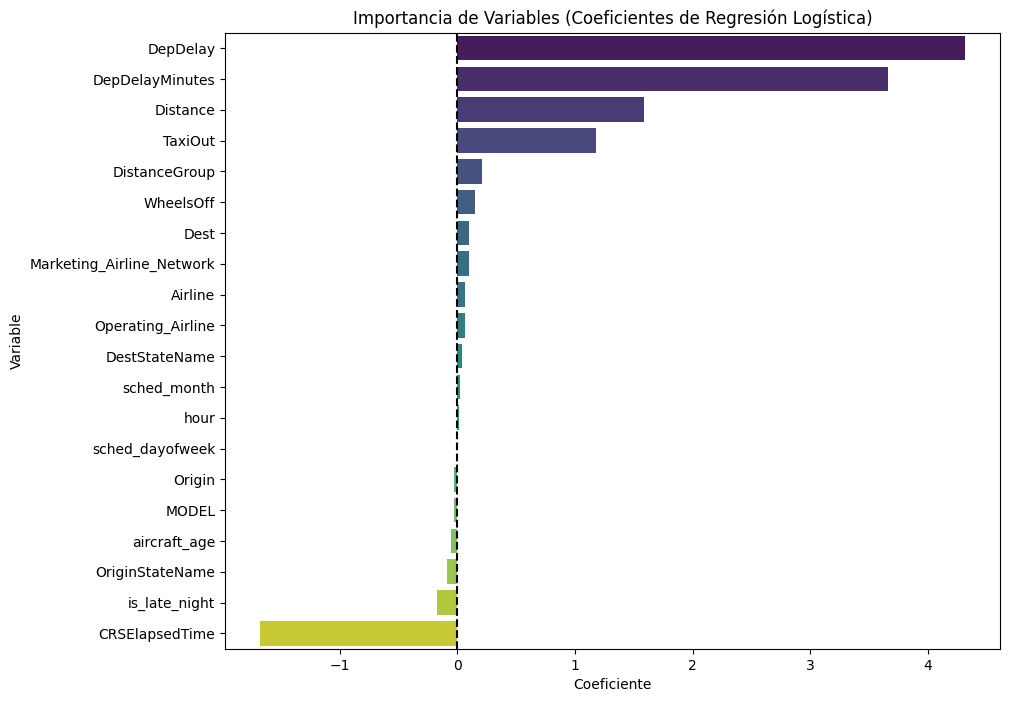

La variable con mayor impacto positivo es: DepDelay


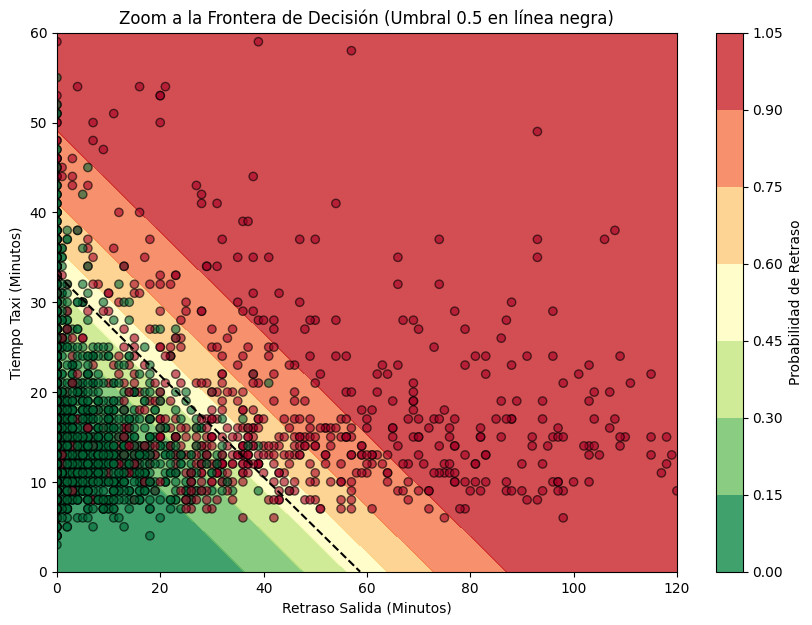

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraemos los coeficientes del modelo entrenado
# Accedemos a través de 'best_model' que es tu GridSearchCV.best_estimator_
model_inner = best_model.named_steps['logreg']
feature_names = X_train_encoded.columns
coefficients = model_inner.coef_[0]

# 2. Creamos un DataFrame para visualizar
importance_df = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefficients
}).sort_values(by='Coeficiente', ascending=False)

# 3. Graficamos
plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Coeficiente', y='Variable', palette='viridis')
plt.title('Importancia de Variables (Coeficientes de Regresión Logística)')
plt.axvline(0, color='black', linestyle='--')
plt.show()

print("La variable con mayor impacto positivo es:", importance_df.iloc[0]['Variable'])


sample = X_test_encoded.sample(5000, random_state=42)
var1 = 'DepDelayMinutes'
var2 = 'TaxiOut'
medians = X_test_encoded.median()
plt.figure(figsize=(10, 7))

# Limitamos a valores razonables (0 a 120 min de retraso y 0 a 60 de taxi)
x_zoom = np.linspace(0, 120, 100)
y_zoom = np.linspace(0, 60, 100)
xx_z, yy_z = np.meshgrid(x_zoom, y_zoom)

# Preparamos datos para la predicción en el zoom
mesh_zoom = pd.DataFrame([medians] * len(xx_z.ravel()))
mesh_zoom[var1] = xx_z.ravel()
mesh_zoom[var2] = yy_z.ravel()

Z_z = best_model.predict_proba(mesh_zoom)[:, 1].reshape(xx_z.shape)

# Dibujamos el mapa de calor con el zoom
contour = plt.contourf(xx_z, yy_z, Z_z, alpha=0.8, cmap='RdYlGn_r')
plt.colorbar(contour, label='Probabilidad de Retraso')

# Dibujamos la "Línea de Decisión" (donde prob = 0.5)
plt.contour(xx_z, yy_z, Z_z, levels=[0.5], colors='black', linestyles='--')

# Solo mostramos puntos que caigan en este rango para no ensuciar
sample_zoom = sample[(sample[var1] <= 120) & (sample[var2] <= 60)]
plt.scatter(sample_zoom[var1], sample_zoom[var2], c=y_test_bin.loc[sample_zoom.index], 
            edgecolors='k', alpha=0.6, cmap='RdYlGn_r')

plt.xlabel('Retraso Salida (Minutos)')
plt.ylabel('Tiempo Taxi (Minutos)')
plt.title('Zoom a la Frontera de Decisión (Umbral 0.5 en línea negra)')
plt.show()

## Arbol de Decision

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Definimos el Pipeline 
# Nota: Los árboles no necesitan StandardScaler, pero mantenemos el imputer por si acaso
tree_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('tree', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# 2. Espacio de búsqueda centrado en la PODA (Pruning)
# ccp_alpha es el parámetro clave para la poda post-entrenamiento
param_grid_tree = {
    'tree__max_depth': [10, 20, None],
    'tree__ccp_alpha': [0.0, 0.001, 0.01],
    'tree__min_samples_leaf': [20, 50]
}

# 3. Configuración del GridSearch
grid_search_tree = GridSearchCV(
    tree_pipeline, 
    param_grid_tree, 
    cv=3, 
    scoring='average_precision', 
    verbose=2, 
    n_jobs=2
)

print("Iniciando entrenamiento del Árbol con Pruning...")
grid_search_tree.fit(X_train_encoded, y_train_bin)

# 4. Resultados del mejor modelo
best_tree = grid_search_tree.best_estimator_
print(f"Mejores parámetros: {grid_search_tree.best_params_}")

y_pred_tree = best_tree.predict(X_test_encoded)
y_probs_tree = best_tree.predict_proba(X_test_encoded)[:, 1]

print("\n--- REPORTE DE CLASIFICACIÓN (ÁRBOL DE DECISIÓN) ---")
print(classification_report(y_test_bin, y_pred_tree))

Iniciando entrenamiento del Árbol con Pruning...
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Mejores parámetros: {'tree__ccp_alpha': 0.0, 'tree__max_depth': 20, 'tree__min_samples_leaf': 50}

--- REPORTE DE CLASIFICACIÓN (ÁRBOL DE DECISIÓN) ---
              precision    recall  f1-score   support

         0.0       0.90      1.00      0.95    252829
         1.0       0.99      0.46      0.63     52548

    accuracy                           0.91    305377
   macro avg       0.95      0.73      0.79    305377
weighted avg       0.92      0.91      0.89    305377



---------------------------------------------
--- DETALLES DEL MEJOR ÁRBOL DE DECISIÓN ---
Profundidad máxima alcanzada: 20 niveles
Cantidad total de hojas (zonas de decisión): 913
Mejores Parámetros: {'tree__ccp_alpha': 0.0, 'tree__max_depth': 20, 'tree__min_samples_leaf': 50}
---------------------------------------------


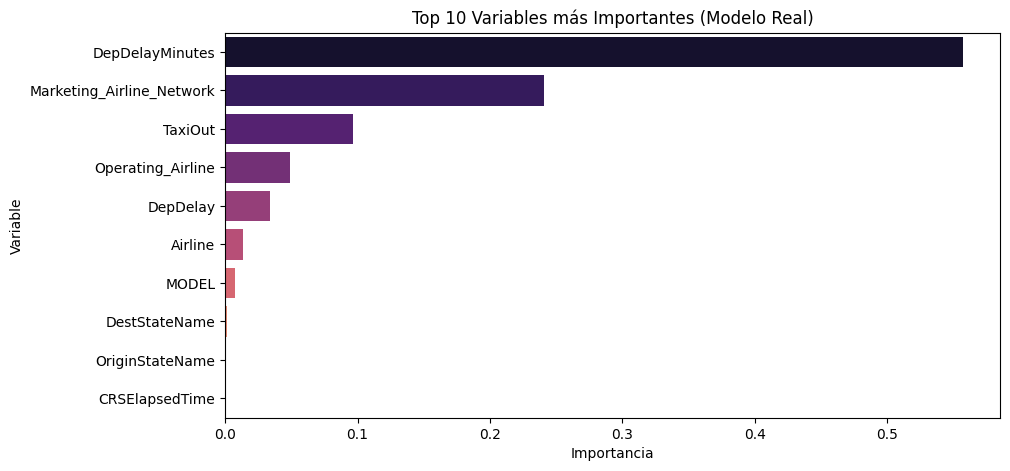

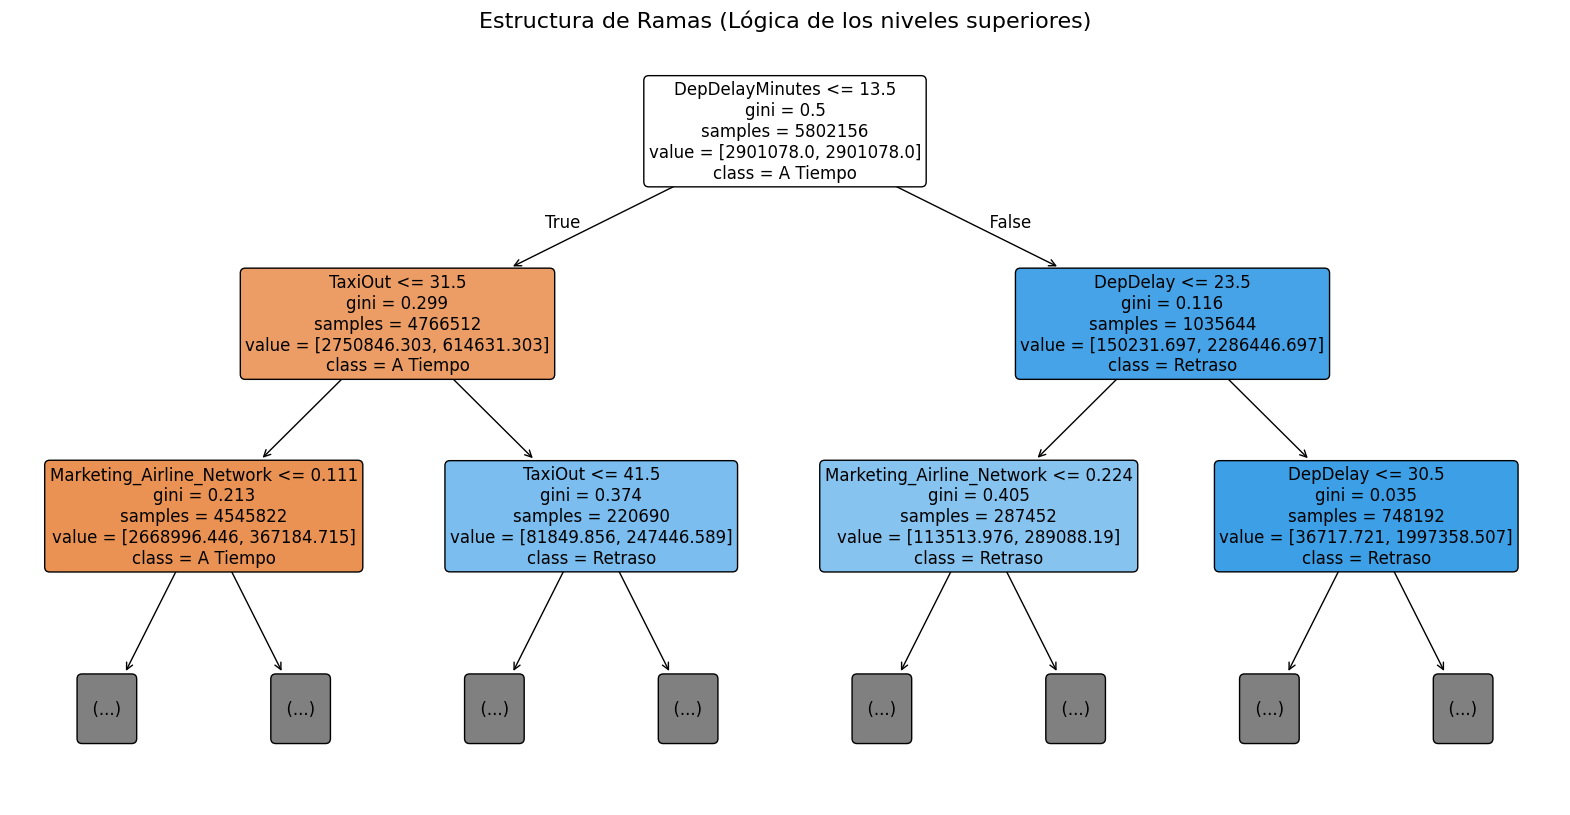

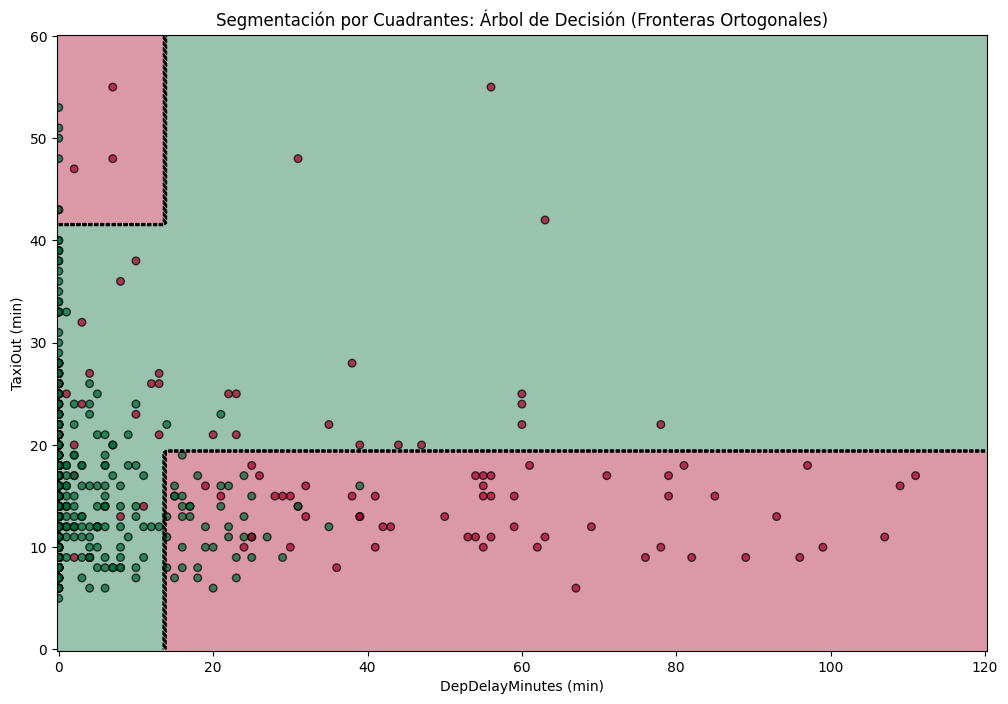

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import plot_tree

# --- 1. DETALLES DEL MEJOR ÁRBOL (Formato exacto solicitado) ---
arbol_ganador = best_tree.named_steps['tree']
print("-" * 45)
print("--- DETALLES DEL MEJOR ÁRBOL DE DECISIÓN ---")
print(f"Profundidad máxima alcanzada: {arbol_ganador.get_depth()} niveles")
print(f"Cantidad total de hojas (zonas de decisión): {arbol_ganador.get_n_leaves()}")
print(f"Mejores Parámetros: {grid_search_tree.best_params_}")
print("-" * 45)

# --- 2. IMPORTANCIA DE VARIABLES (TOP 10) ---
tree_imp_df = pd.DataFrame({
    'Variable': X_train_encoded.columns,
    'Importancia': arbol_ganador.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=tree_imp_df.head(10), x='Importancia', y='Variable', hue='Variable', palette='magma', legend=False)
plt.title('Top 10 Variables más Importantes (Modelo Real)')
plt.show()

# --- 3. ESTRUCTURA DE RAMAS ---
plt.figure(figsize=(20, 10))
plot_tree(arbol_ganador, feature_names=list(X_train_encoded.columns), 
          class_names=['A Tiempo', 'Retraso'], filled=True, rounded=True, 
          max_depth=2, fontsize=12)
plt.title("Estructura de Ramas (Lógica de los niveles superiores)", fontsize=16)
plt.show()

# --- 4. LA GRÁFICA DE BLOQUES (Segmentación visible) ---
# Usamos DepDelayMinutes y TaxiOut como ejes
v1, v2 = 'DepDelayMinutes', 'TaxiOut'

# Creamos una malla densa en el rango donde hay más confusión
x_range = np.linspace(0, 120, 250) 
y_range = np.linspace(0, 60, 250)
xx, yy = np.meshgrid(x_range, y_range)

# Preparar DataFrame para el modelo con TODAS las columnas
X_vis = pd.DataFrame(columns=X_train_encoded.columns)
mesh_points = np.c_[xx.ravel(), yy.ravel()]
X_vis[v1] = mesh_points[:, 0]
X_vis[v2] = mesh_points[:, 1]

# Rellenamos el resto. TRUCO: Usamos un percentil alto de DepDelay para 
# que el modelo entre en "modo alerta" y nos muestre sus bloques de decisión.
for col in X_vis.columns:
    if col not in [v1, v2]:
        X_vis[col] = X_test_encoded[col].quantile(0.75) # Valor más sensible que la mediana

# Predicción de CLASE para ver cuadrantes sólidos
Z_blocks = best_tree.predict(X_vis).reshape(xx.shape)

plt.figure(figsize=(12, 8))

# pcolormesh para ver los bloques verdes y rojos perfectamente definidos
plt.pcolormesh(xx, yy, Z_blocks, cmap='RdYlGn_r', alpha=0.4, shading='auto')

# Dibujamos las líneas de los bloques (la "gracia" ortogonal del árbol)
plt.contour(xx, yy, Z_blocks, colors='black', linewidths=0.8, linestyles='--')

# Superponemos una muestra de puntos reales
sample_plot = X_test_encoded[(X_test_encoded[v1] <= 120) & (X_test_encoded[v2] <= 60)].sample(800, random_state=42)
plt.scatter(sample_plot[v1], sample_plot[v2], c=y_test_bin.loc[sample_plot.index], 
            edgecolors='k', alpha=0.7, cmap='RdYlGn_r', s=30)

plt.xlabel(f'{v1} (min)')
plt.ylabel(f'{v2} (min)')
plt.title('Segmentación por Cuadrantes: Árbol de Decisión (Fronteras Ortogonales)')
plt.show()

## Random Forest

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

# 1. MUESTRA ESTRATÉGICA (20% para capturar la esencia de los 6.5M)
X_train_sample = X_train_encoded.sample(frac=0.2, random_state=42)
y_train_sample = y_train_bin.loc[X_train_sample.index]

# 2. BÚSQUEDA AMPLIADA (Para aprovechar tus 20 min de límite)
# He subido n_iter de 4 a 10 para probar más combinaciones
param_dist_rf = {
    'n_estimators': [100, 150, 200], # Más árboles para mayor estabilidad
    'max_depth': [15, 20, 25],        # Un poco más de profundidad para competir con el árbol original
    'min_samples_leaf': [30, 50, 70],  # Ajustamos el tamaño de hoja para el equilibrio
    'max_features': ['sqrt', 'log2']   # Forzamos a que los árboles no siempre vean lo mismo
}

print(f"Buscando mejores parámetros en muestra de {len(X_train_sample)} filas...")
random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1), 
    param_distributions=param_dist_rf, 
    n_iter=8,      # 8 iteraciones x 2 folds = 16 fits (Debería rondar los 15-18 min)
    cv=2, 
    scoring='f1', 
    verbose=3 
)

random_search_rf.fit(X_train_sample, y_train_sample)

# 3. ENTRENAMIENTO FINAL EN EL DATASET COMPLETO (6.5M)
print(f"\nMejores parámetros encontrados: {random_search_rf.best_params_}")
print("Entrenando modelo final en el set de 6.5M (Paciencia, aquí no hay verbose)...")

best_rf = RandomForestClassifier(
    **random_search_rf.best_params_, 
    n_jobs=-1, 
    random_state=42
)
best_rf.fit(X_train_encoded, y_train_bin)

# 4. REPORTE DE MÉTRICAS DETALLADO
print("\n" + "="*50)
print("--- REPORTE DE RENDIMIENTO: RANDOM FOREST FINAL ---")
print("="*50)

y_pred_rf = best_rf.predict(X_test_encoded)

# Métricas clásicas
print(classification_report(y_test_bin, y_pred_rf))

# Matriz de Confusión para el reporte
cm = confusion_matrix(y_test_bin, y_pred_rf)
print("\nMatriz de Confusión:")
print(f"Verdaderos Negativos (A tiempo): {cm[0][0]}")
print(f"Falsos Positivos (Alarma falsa): {cm[0][1]}")
print(f"Falsos Negativos (Retraso no visto): {cm[1][0]}")
print(f"Verdaderos Positivos (Retraso detectado): {cm[1][1]}")

print(f"\nAccuracy Global: {accuracy_score(y_test_bin, y_pred_rf):.4f}")
print("="*50)

Buscando mejores parámetros en muestra de 1160431 filas...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
[CV 1/2] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=200;, score=0.974 total time=  31.3s
[CV 2/2] END max_depth=20, max_features=sqrt, min_samples_leaf=50, n_estimators=200;, score=0.975 total time=  32.5s
[CV 1/2] END max_depth=25, max_features=sqrt, min_samples_leaf=30, n_estimators=200;, score=0.986 total time=  35.1s
[CV 2/2] END max_depth=25, max_features=sqrt, min_samples_leaf=30, n_estimators=200;, score=0.986 total time=  35.2s
[CV 1/2] END max_depth=25, max_features=sqrt, min_samples_leaf=70, n_estimators=200;, score=0.969 total time=  33.3s
[CV 2/2] END max_depth=25, max_features=sqrt, min_samples_leaf=70, n_estimators=200;, score=0.968 total time=  33.7s
[CV 1/2] END max_depth=15, max_features=log2, min_samples_leaf=70, n_estimators=150;, score=0.940 total time=  22.6s
[CV 2/2] END max_depth=15, max_features=log2, min_samples_leaf

![Tradeoff](https://media.licdn.com/dms/image/v2/D4D12AQHQkI-Op4l9KQ/article-cover_image-shrink_600_2000/article-cover_image-shrink_600_2000/0/1711746268059?e=2147483647&v=beta&t=U7GG2Ej3rnG3hUY1X_WXs92yxzqRJ3hkLH5hzluO9zQ)

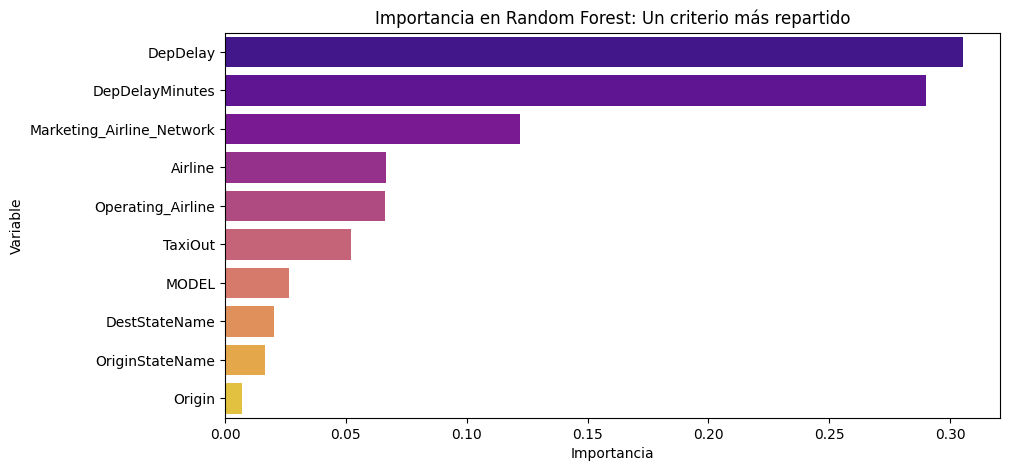

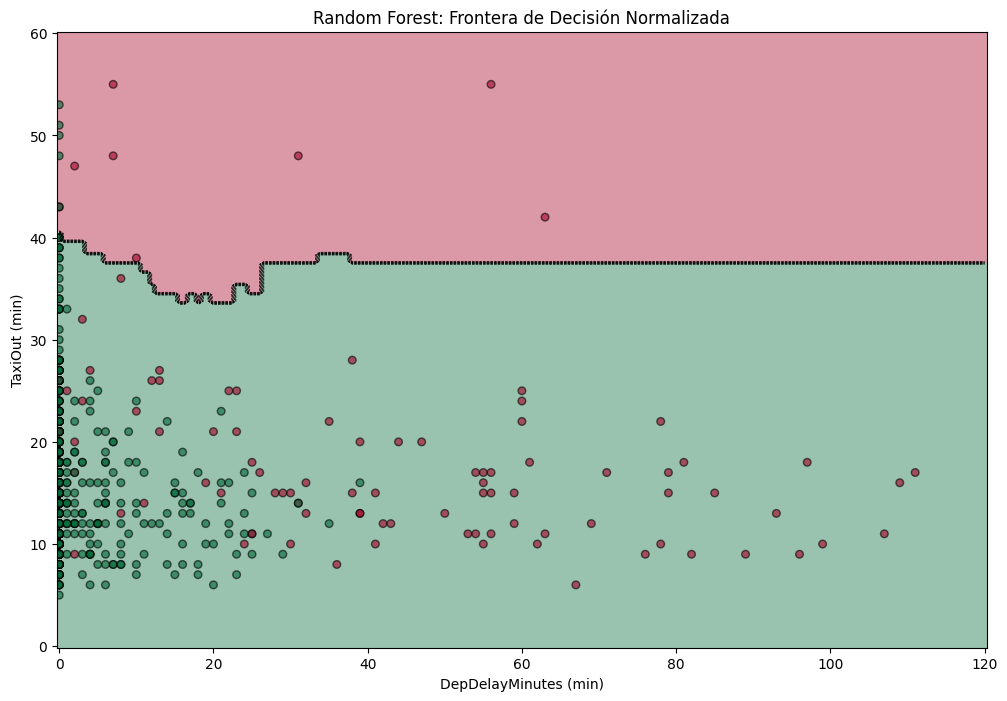

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

# --- 4. IMPORTANCIA DE VARIABLES ---
rf_imp_df = pd.DataFrame({
    'Variable': X_train_encoded.columns, # CAMBIO: X_train_encoded
    'Importancia': best_rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_imp_df.head(10), x='Importancia', y='Variable', hue='Variable', palette='plasma', legend=False)
plt.title('Importancia en Random Forest: Un criterio más repartido')
plt.show()

# --- 5. SEGMENTACIÓN POR CUADRANTES ---
v1, v2 = 'DepDelayMinutes', 'TaxiOut'
x_range = np.linspace(0, 120, 200)
y_range = np.linspace(0, 60, 200)
xx, yy = np.meshgrid(x_range, y_range)

X_vis_rf = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=[v1, v2])
# CAMBIO: Iteramos sobre X_train_encoded
for col in X_train_encoded.columns: 
    if col not in [v1, v2]:
        X_vis_rf[col] = X_test_encoded[col].quantile(0.75) 

X_vis_rf = X_vis_rf[X_train_encoded.columns] 
Z_rf = best_rf.predict(X_vis_rf).reshape(xx.shape)

plt.figure(figsize=(12, 8))
plt.pcolormesh(xx, yy, Z_rf, cmap='RdYlGn_r', alpha=0.4, shading='auto')
plt.contour(xx, yy, Z_rf, colors='black', linewidths=0.5, linestyles='--')

# Puntos reales usando X_test_encoded
sample = X_test_encoded[(X_test_encoded[v1] <= 120) & (X_test_encoded[v2] <= 60)].sample(800, random_state=42)
plt.scatter(sample[v1], sample[v2], c=y_test_bin.loc[sample.index], 
            edgecolors='k', alpha=0.6, cmap='RdYlGn_r', s=30)

plt.xlabel(f'{v1} (min)')
plt.ylabel(f'{v2} (min)')
plt.title('Random Forest: Frontera de Decisión Normalizada')
plt.show()

-	El model RF, al usar particiones sin una variable hace que DepDelay Minutes tenga una menor importancia en comparación al resto. Podemos ver que modelo y Airline ganan muchísima mas importancia. Aun asi esto refleja el porque el Recall en la clase 1 es menor que el de un árbol de decisión. Tambien puede ser afectado por como se hizo la búsqueda de hiperparametros.

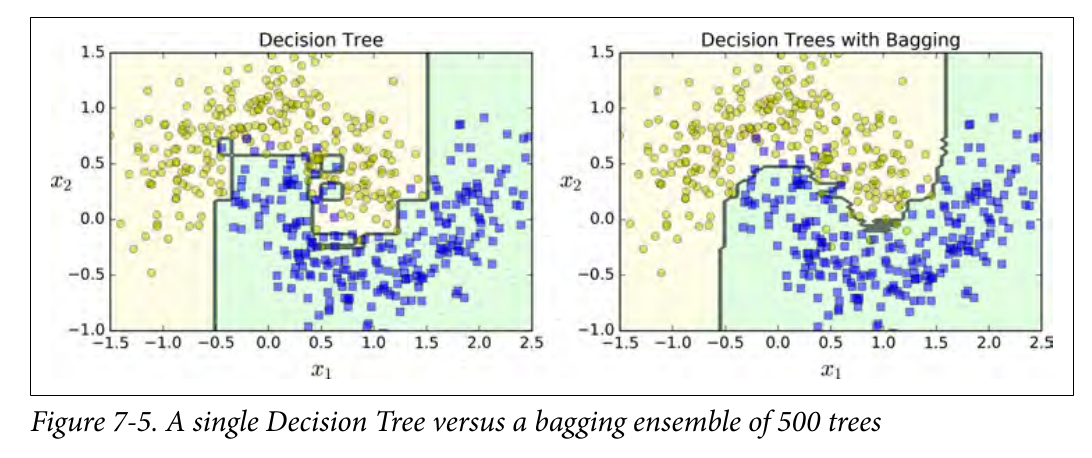

## XGBoost

In [63]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# 1. ESPACIO DE BÚSQUEDA AGRESIVO Y DESEQUILIBRADO
param_dist_failed = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 15, 20],           # Árboles profundos: se aprenden el ruido de memoria
    'learning_rate': [0.001, 0.01, 0.1], # Mezclamos velocidades: las lentas con mucha profundidad causan overfitting
    'scale_pos_weight': [10, 20]         # Forzamos una "paranoia" extrema por los retrasos
}

xgb_failed = XGBClassifier(tree_method='hist', random_state=42)

# Buscamos optimizar solo Accuracy (esto es lo que engaña al modelo)
rs_failed = RandomizedSearchCV(
    xgb_failed, 
    param_distributions=param_dist_failed, 
    n_iter=5, 
    scoring='accuracy', 
    cv=3, 
    verbose=1
)

rs_failed.fit(X_train_encoded, y_train_bin)

# 2. RESULTADOS DEL MODELO "MALO"
best_failed_params = rs_failed.best_params_
y_pred_failed = rs_failed.predict(X_test_encoded)

print("\n--- CONFIGURACIÓN DEL MODELO FALLIDO ---")
print(f"Mejores parámetros encontrados (RandomSearch): {best_failed_params}")
print("\n--- INFORME DE CLASIFICACIÓN (MODELO FALLIDO) ---")
print(classification_report(y_test_bin, y_pred_failed))

Fitting 3 folds for each of 5 candidates, totalling 15 fits

--- CONFIGURACIÓN DEL MODELO FALLIDO ---
Mejores parámetros encontrados (RandomSearch): {'scale_pos_weight': 10, 'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.1}

--- INFORME DE CLASIFICACIÓN (MODELO FALLIDO) ---
              precision    recall  f1-score   support

         0.0       1.00      0.00      0.00    252829
         1.0       0.17      1.00      0.29     52548

    accuracy                           0.17    305377
   macro avg       0.59      0.50      0.15    305377
weighted avg       0.86      0.17      0.05    305377



--- XGBOOST MAESTRO CONFIGURADO ---
Punto óptimo detectado en iteración: 180
Umbral óptimo calculado: 0.48
              precision    recall  f1-score   support

         0.0       0.95      0.98      0.97    252829
         1.0       0.88      0.76      0.82     52548

    accuracy                           0.94    305377
   macro avg       0.92      0.87      0.89    305377
weighted avg       0.94      0.94      0.94    305377



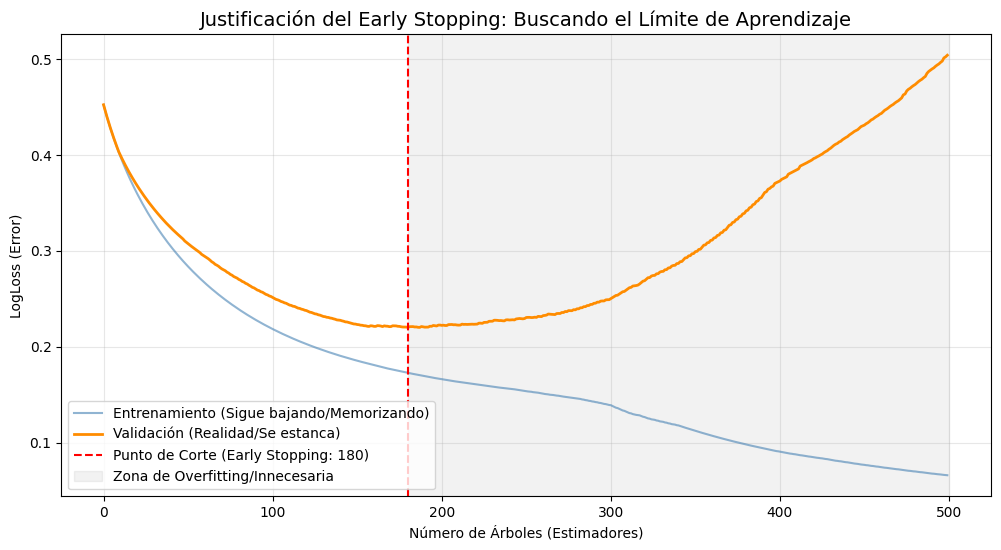

In [59]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score
import numpy as np
import matplotlib.pyplot as plt

# 1. MODELO MAESTRO (CON EARLY STOPPING)
model_master_v2 = XGBClassifier(
    n_estimators=500, max_depth=3, learning_rate=0.01,
    scale_pos_weight=1, tree_method='hist', random_state=42,
    early_stopping_rounds=10
)

model_master_v2.fit(
    X_train_encoded, y_train_bin,
    eval_set=[(X_train_encoded, y_train_bin), (X_test_encoded, y_test_bin)],
    verbose=False
)

# Guardamos en qué punto exacto paró el maestro
best_iteration = model_master_v2.best_iteration

# 2. MODELO DE CONTROL (SIN EARLY STOPPING PARA COMPARAR)
model_overfit = XGBClassifier(
    n_estimators=500, max_depth=3, learning_rate=0.01,
    scale_pos_weight=1, tree_method='hist', random_state=42
)
model_overfit.fit(
    X_train_encoded, y_train_bin,
    eval_set=[(X_train_encoded, y_train_bin), (X_test_encoded, y_test_bin)],
    verbose=False
)

# 3. GENERACIÓN DEL INFORME (DEL MODELO MAESTRO)
y_probs_xgb = model_master_v2.predict_proba(X_test_encoded)[:, 1]
thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_test_bin, y_probs_xgb > t) for t in thresholds]
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_final = (y_probs_xgb > best_threshold).astype(int)

print(f"--- XGBOOST MAESTRO CONFIGURADO ---")
print(f"Punto óptimo detectado en iteración: {best_iteration}")
print(f"Umbral óptimo calculado: {best_threshold:.2f}")
print(classification_report(y_test_bin, y_pred_final))

# 4. GRÁFICA COMPARATIVA: ¿POR QUÉ PARAR AHÍ?
results_over = model_overfit.evals_result()

plt.figure(figsize=(12, 6))
# Dibujamos lo que pasó hasta el final para que se vea el estancamiento/overfitting
plt.plot(results_over['validation_0']['logloss'], label='Entrenamiento (Sigue bajando/Memorizando)', color='steelblue', alpha=0.6)
plt.plot(results_over['validation_1']['logloss'], label='Validación (Realidad/Se estanca)', color='darkorange', linewidth=2)

# Marcamos el punto donde el Maestro decidió parar
plt.axvline(x=best_iteration, color='red', linestyle='--', label=f'Punto de Corte (Early Stopping: {best_iteration})')

# Sombreado para resaltar la zona de "vicio" o innecesaria
plt.axvspan(best_iteration, 500, color='gray', alpha=0.1, label='Zona de Overfitting/Innecesaria')

plt.title('Justificación del Early Stopping: Buscando el Límite de Aprendizaje', fontsize=14)
plt.xlabel('Número de Árboles (Estimadores)')
plt.ylabel('LogLoss (Error)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

model_master = model_master_v2

## Comparacion

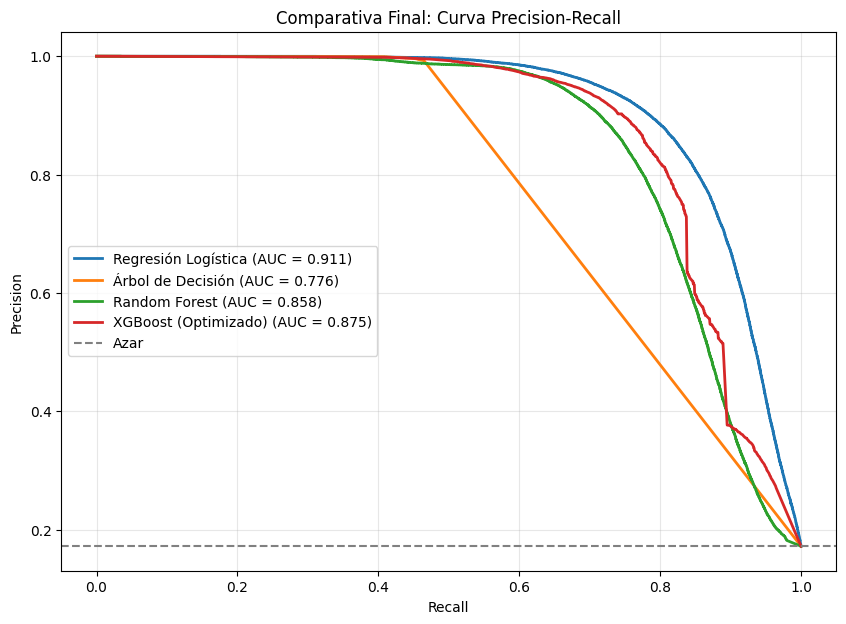


📊 TABLA COMPARATIVA FINAL
              Modelo  Accuracy  Precision   Recall  F1-Score   AUC-PR
XGBoost (Optimizado)  0.941705   0.882177 0.763150  0.818358 0.875044
 Regresión Logística  0.923197   0.728748 0.881937  0.798058 0.911077
   Árbol de Decisión  0.907308   0.993084 0.464566  0.633009 0.776038
       Random Forest  0.894972   0.995451 0.391433  0.561910 0.857727


In [53]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc, f1_score, precision_score, recall_score, accuracy_score
import pandas as pd

# Definimos los modelos a comparar
models = {
    'Regresión Logística': best_model,
    'Árbol de Decisión': best_tree,
    'Random Forest': best_rf,
    'XGBoost (Optimizado)': model_master
}

results = []
plt.figure(figsize=(10, 7))

for name, model in models.items():
    # Ajuste de columnas
    cols = model.feature_names_in_ if hasattr(model, 'feature_names_in_') else X_train_encoded.columns
    X_eval = X_test_encoded[cols]
    
    # Probabilidades
    y_probs = model.predict_proba(X_eval)[:, 1]
    
    # APLICAMOS UMBRAL: best_threshold para XGBoost, 0.5 para el resto
    umbral = best_threshold if 'XGBoost' in name else 0.5
    y_pred = (y_probs > umbral).astype(int)
    
    # Métricas
    precision_vals, recall_vals, _ = precision_recall_curve(y_test_bin, y_probs)
    pr_auc = auc(recall_vals, precision_vals)
    
    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test_bin, y_pred),
        'Precision': precision_score(y_test_bin, y_pred),
        'Recall': recall_score(y_test_bin, y_pred),
        'F1-Score': f1_score(y_test_bin, y_pred),
        'AUC-PR': pr_auc
    })
    
    plt.plot(recall_vals, precision_vals, label=f'{name} (AUC = {pr_auc:.3f})', linewidth=2)

# Estética y Tabla
plt.axhline(y=y_test_bin.mean(), color='grey', linestyle='--', label='Azar')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Comparativa Final: Curva Precision-Recall')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

df_resumen = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False)
print("\n📊 TABLA COMPARATIVA FINAL")
print(df_resumen.to_string(index=False))

El éxito del modelo depende del usuario: mientras una aerolínea prioriza la Precisión para evitar los altos costes logísticos de mover personal y puertas ante falsas alarmas, un pasajero prefiere el Recall para estar prevenido ante un posible retraso, aunque el modelo falle por ser precavido.

1. **XGBoost (Optimizado):** El equilibrio operativo.Alcanza el F1-Score más alto (0.82). Es el modelo más completo porque, tras la optimización del umbral, logra una fiabilidad del 88% detectando la gran mayoría de los retrasos. Es la herramienta ideal para una gestión eficiente que no quiere saturar el sistema con falsas alarmas.
2. **Regresión Logística:** El detector de máxima sensibilidad.Presenta el Recall más alto (0.88) y el mejor AUC-PR (0.91). Su excelente rendimiento confirma que los retrasos en este dataset son linealmente separables; es el modelo preferido para el pasajero, ya que es el que menos retrasos reales deja escapar.
3. **Árbol de Decisión:**  Logra un Recall superior (0.46) al del Random Forest. Esto ocurre porque el árbol tiene libertad total para usar la variable más potente (DepDelayMinutes) en cada nodo, permitiéndole capturar casi la mitad de los retrasos mediante reglas de decisión claras y sin restricciones de variables.
4. **Random Forest:** Aunque ofrece la Precisión más alta (99.5%), su Recall (0.39) es el más bajo debido a su arquitectura. Al seleccionar variables mediante la raíz cuadrada del total, muchos de sus árboles son forzados a no ver DepDelayMinutes. Esta "dilución" de la variable principal lo vuelve extremadamente conservador: solo avisa cuando muchas variables secundarias coinciden, lo que evita falsas alarmas pero lo hace ignorar el 61% de los retrasos reales.

# **Modelo de Regresion:** Retraso en Minutos (Arrival)

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd
from category_encoders import LeaveOneOutEncoder

# --- 0. LIMPIEZA PREVENTIVA DE NULOS (Vital para SGD y Age) ---
# Definimos las columnas críticas que no pueden tener nulos
target_reg = 'ArrDelayMinutes'
# Identificamos columnas que sabemos que pueden traer nulos como aircraft_age
cols_critical = [target_reg, 'aircraft_age', 'DepDelayMinutes', 'TaxiOut'] 

# Eliminamos filas donde falten datos en estas columnas clave antes de nada
# Esto evita el error de memoria y el error de ejecución del modelo
df = df.dropna(subset=[c for c in cols_critical if c in df.columns])

# --- 1. CONFIGURACIÓN DEL SPLIT PARA REGRESIÓN ---
# Elimino el target actual y el resto de variables de "futuro" (Leakage)
cols_to_drop_initial = [
    target_reg, 'ArrDel15', 'TotalDelayMinutes', 'TotalDelayMinutes.1', 'ArrDelay', 
    'TaxiIn', 'WheelsOn', 'ActualElapsedTime', 
    'ArrivalDelayGroups', 'DepartureDelayGroups', 'DivAirportLandings',
    'DepDel15', "AirTime"
]

X_reg = df.drop(columns=[c for c in cols_to_drop_initial if c in df.columns])
y_reg = df[target_reg]

# Mantengo mi split al 5% para test dado que manejo más de 6 millones de registros
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.05, random_state=42
)

print(f"Split para regresión completado. Filas finales: {len(df)}")

# --- 2. EXTRACCIÓN DE VARIABLES TEMPORALES ---
def extract_time_features(df_input):
    df_out = df_input.copy()
    df_out['sched_dep_dt'] = pd.to_datetime(df_out['sched_dep_dt'])
    df_out['sched_month'] = df_out['sched_dep_dt'].dt.month
    df_out['sched_dayofweek'] = df_out['sched_dep_dt'].dt.dayofweek
    df_out['hour'] = df_out['sched_dep_dt'].dt.hour
    df_out['is_late_night'] = (df_out['hour'] >= 18).astype(int)
    return df_out

X_train_reg = extract_time_features(X_train_reg)
X_test_reg = extract_time_features(X_test_reg)

# --- 3. SELECCIÓN Y LIMPIEZA FINAL ---
target_encode_cols = [
    'Airline', 'Origin', 'Dest', 'MODEL', 
    'Marketing_Airline_Network', 'Operating_Airline',
    'OriginStateName', 'DestStateName'
]

cols_to_drop_final = [
    'FlightDate', 'sched_dep_dt', 'sched_arr_dt', 'dep_dt', 'arr_dt', 
    'Tail_Number', 'Flight_Number_Marketing_Airline', 'Flight_Number_Operating_Airline', 
    'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginState', 'OriginStateFips', 'OriginWac',
    'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestState', 'DestStateFips', 'DestWac',
    'OriginCityName', 'DestCityName', 'DepTimeBlk', 'ArrTimeBlk',
    'origin_lat', 'origin_lon', 'dest_lat', 'dest_lon',
    'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 
    'IATA_Code_Marketing_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline'
]

X_train_reg = X_train_reg.drop(columns=[c for c in cols_to_drop_final if c in X_train_reg.columns])
X_test_reg = X_test_reg.drop(columns=[c for c in cols_to_drop_final if c in X_test_reg.columns])

# --- 4. LEAVE-ONE-OUT ENCODING PARA REGRESIÓN ---
loo_encoder_reg = LeaveOneOutEncoder(cols=target_encode_cols)

print("Iniciando codificación Leave-One-Out para regresión...")
X_train_reg_encoded = loo_encoder_reg.fit_transform(X_train_reg, y_train_reg)
X_test_reg_encoded = loo_encoder_reg.transform(X_test_reg)

# Blindaje final: rellenamos con 0 si el encoder generó algún nulo por categorías nuevas en test
X_train_reg_encoded = X_train_reg_encoded.fillna(0)
X_test_reg_encoded = X_test_reg_encoded.fillna(0)

print("Codificación de regresión finalizada.")
print(f"Variables listas para entrenar: {X_train_reg_encoded.columns.tolist()}")

Split para regresión completado. Filas finales: 5475597
Iniciando codificación Leave-One-Out para regresión...
Codificación de regresión finalizada.
Variables listas para entrenar: ['Airline', 'Origin', 'Dest', 'DepDelayMinutes', 'DepDelay', 'CRSElapsedTime', 'Distance', 'Marketing_Airline_Network', 'Operating_Airline', 'OriginStateName', 'DestStateName', 'TaxiOut', 'WheelsOff', 'DistanceGroup', 'aircraft_age', 'MODEL', 'sched_month', 'sched_dayofweek', 'hour', 'is_late_night']


In [16]:
from sklearn.preprocessing import StandardScaler

# 1. ESCALADO DE VARIABLES (Sobre el total de los datos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg_encoded)
X_test_scaled = scaler.transform(X_test_reg_encoded)

## Lineal


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# 1. ESCALADO DE VARIABLES (Sobre el total de los datos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reg_encoded)
X_test_scaled = scaler.transform(X_test_reg_encoded)

# 2. BÚSQUEDA DE HIPERPARÁMETROS CON EL DATASET COMPLETO
# Definimos el espacio de búsqueda para Lasso, Ridge y ElasticNet
param_dist_sgd = {
    'penalty': ['l2', 'l1', 'elasticnet', None],
    'alpha': [1e-4, 1e-3, 1e-2, 0.1],       # Fuerza de la penalización
    'l1_ratio': [0.15, 0.5, 0.85]           # Mix L1/L2 para ElasticNet
}

print("Iniciando RandomizedSearchCV sobre el 100% del dataset (6 millones de filas)...")
# Nota: n_jobs=-1 usará todos tus núcleos para procesar los 30 fits (10 iter x 3 folds)
sgd_rs = RandomizedSearchCV(
    SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
    param_distributions=param_dist_sgd,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=3,
    n_jobs=10,
    random_state=42
)

# Ajuste directo sobre TODO el set de entrenamiento
sgd_rs.fit(X_train_scaled, y_train_reg)
best_sgd = sgd_rs.best_estimator_

print(f"Mejor configuración encontrada: {sgd_rs.best_params_}")

# 3. ENTRENAMIENTO FINAL
# Aunque RandomizedSearchCV ya deja el modelo entrenado, 
# best_sgd ya contiene los pesos óptimos tras el fit.
print("Entrenamiento completado.")

# 4. PREDICCIÓN Y EVALUACIÓN
y_pred_sgd = best_sgd.predict(X_test_scaled)

# Métricas finales
r2_sgd = r2_score(y_test_reg, y_pred_sgd)
rmse_sgd = np.sqrt(mean_squared_error(y_test_reg, y_pred_sgd))
mae_sgd = mean_absolute_error(y_test_reg, y_pred_sgd)

print(f"\n--- RENDIMIENTO DEL MODELO LINEAL (FULL DATASET SEARCH) ---")
print(f"R² (Coeficiente de Determinación): {r2_sgd:.4f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse_sgd:.2f} minutos")
print(f"MAE (Error Absoluto Medio): {mae_sgd:.2f} minutos")

Iniciando RandomizedSearchCV sobre el 100% del dataset (6 millones de filas)...
Mejor configuración encontrada: {'penalty': None, 'l1_ratio': 0.15, 'alpha': 0.01}
Entrenamiento completado.

--- RENDIMIENTO DEL MODELO LINEAL (FULL DATASET SEARCH) ---
R² (Coeficiente de Determinación): 0.9731
RMSE (Raíz del Error Cuadrático Medio): 7.67 minutos
MAE (Error Absoluto Medio): 4.60 minutos


Iniciando Curva de Aprendizaje de ALTA RESOLUCIÓN (30 puntos)...
[learning_curve] Training set sizes: [  34678  153064  271451  389837  508223  626609  744995  863382  981768
 1100154 1218540 1336926 1455312 1573699 1692085 1810471 1928857 2047243
 2165630 2284016 2402402 2520788 2639174 2757560 2875947 2994333 3112719
 3231105 3349491 3467878]


[Parallel(n_jobs=10)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  90 out of  90 | elapsed:  5.1min finished


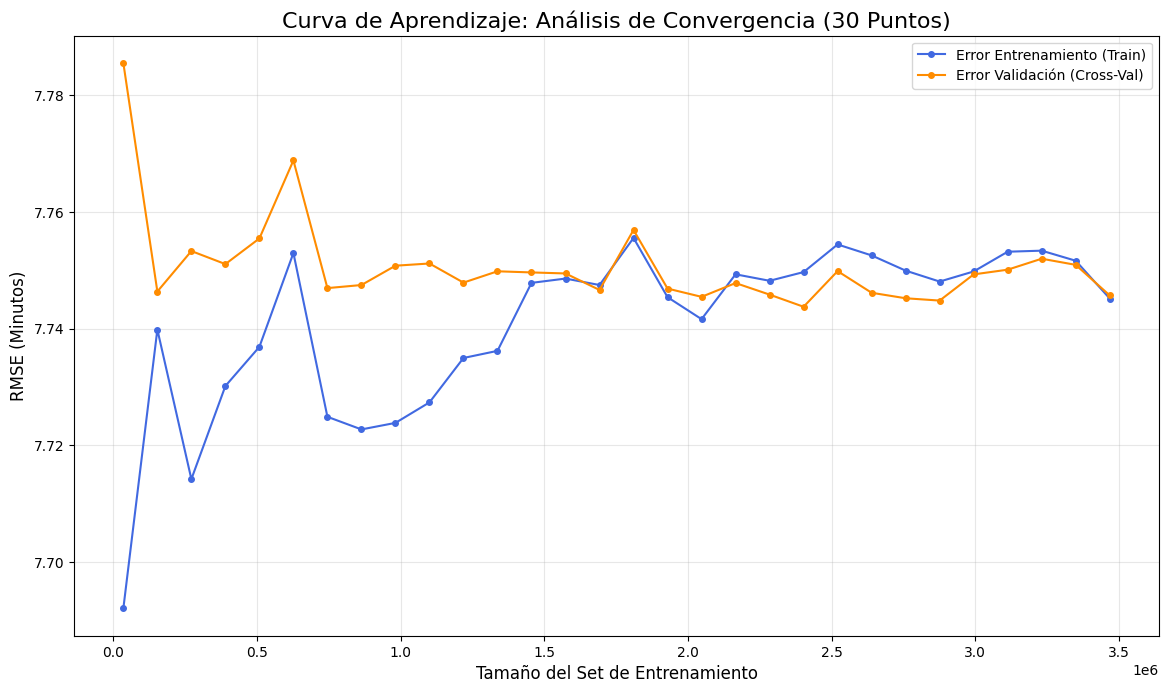

RMSE inicial (1% datos): 7.7855
RMSE final (100% datos): 7.7457
Mejora total: 0.0398 minutos


In [27]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

# Usamos el modelo con los mejores parámetros (penalty=None)
final_model_sgd = SGDRegressor(penalty=None, max_iter=1000, tol=1e-3, random_state=42)

print("Iniciando Curva de Aprendizaje de ALTA RESOLUCIÓN (30 puntos)...")

# 30 puntos repartidos desde el 1% hasta el 100% del dataset
train_sizes, train_scores, val_scores = learning_curve(
    final_model_sgd, 
    X_train_scaled, 
    y_train_reg, 
    train_sizes=np.linspace(0.01, 1.0, 30), # 30 cortes para máxima precisión
    scoring='neg_root_mean_squared_error', 
    cv=3, 
    n_jobs=10,
    verbose=1
)

# Cálculos de media y desviación
train_rmse_mean = -np.mean(train_scores, axis=1)
val_rmse_mean = -np.mean(val_scores, axis=1)

# Gráfico de alta definición
plt.figure(figsize=(14, 8))
plt.plot(train_sizes, train_rmse_mean, 'o-', color="royalblue", label="Error Entrenamiento (Train)", markersize=4)
plt.plot(train_sizes, val_rmse_mean, 'o-', color="darkorange", label="Error Validación (Cross-Val)", markersize=4)

plt.title("Curva de Aprendizaje: Análisis de Convergencia (30 Puntos)", fontsize=16)
plt.xlabel("Tamaño del Set de Entrenamiento", fontsize=12)
plt.ylabel("RMSE (Minutos)", fontsize=12)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# Eliminamos el tight_layout que daba error y usamos ajuste manual
plt.subplots_adjust(bottom=0.15, top=0.9)
plt.show()

# Resumen de convergencia para tu informe
print(f"RMSE inicial (1% datos): {val_rmse_mean[0]:.4f}")
print(f"RMSE final (100% datos): {val_rmse_mean[-1]:.4f}")
print(f"Mejora total: {val_rmse_mean[0] - val_rmse_mean[-1]:.4f} minutos")

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# 1. SELECCIÓN DE COLUMNAS
numeric_cols_to_poly = ['DepDelayMinutes', 'Distance', 'aircraft_age', 'hour', 'CRSElapsedTime']
other_cols = [c for c in X_train_reg_encoded.columns if c not in numeric_cols_to_poly]

# 2. MUESTREO (5%)
X_search = X_train_reg_encoded.sample(frac=0.05, random_state=42)
y_search = y_train_reg.loc[X_search.index]

# 3. PIPELINE
preprocessor = ColumnTransformer(transformers=[
    ('poly', PolynomialFeatures(include_bias=False), numeric_cols_to_poly),
    ('keep', 'passthrough', other_cols)
])

poly_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('scaler', StandardScaler()),
    ('sgd', SGDRegressor(max_iter=1000, tol=1e-3, random_state=42))
])

# 4. BÚSQUEDA
param_dist = {
    'preprocessor__poly__degree': [2, 3], 
    'sgd__alpha': [1e-4, 1e-3, 0.01],
    'sgd__penalty': ['l2', 'l1', 'elasticnet']
}

print("Iniciando búsqueda de hiperparámetros...")
search = RandomizedSearchCV(poly_pipeline, param_distributions=param_dist, n_iter=6, cv=2, scoring='r2', n_jobs=-1, verbose=1, random_state=42)
search.fit(X_search, y_search)
best_degree = search.best_params_['preprocessor__poly__degree']

# 5. ENTRENAMIENTO FINAL
print(f"Entrenando modelo final (Grado {best_degree})...")
final_poly_model = search.best_estimator_
final_poly_model.fit(X_train_reg_encoded, y_train_reg)

# 6. PREDICCIÓN (Aquí está el cambio clave: guardamos en y_pred_poly)
y_pred_poly = final_poly_model.predict(X_test_reg_encoded)

print("\n" + "═"*45)
print("      MI REPORTE POLINÓMICO")
print("═"*45)
print(f"R²: {r2_score(y_test_reg, y_pred_poly):.4f}")
print("═"*45)
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_reg, y_pred_poly)):.2f} minutos")
print(f"MAE: {mean_absolute_error(y_test_reg, y_pred_poly):.2f} minutos")
print("═"*45)

Iniciando búsqueda de hiperparámetros...
Fitting 2 folds for each of 6 candidates, totalling 12 fits
Entrenando modelo final (Grado 2)...

═════════════════════════════════════════════
      MI REPORTE POLINÓMICO
═════════════════════════════════════════════
R²: 0.9739
═════════════════════════════════════════════
RMSE: 7.56 minutos
MAE: 4.49 minutos
═════════════════════════════════════════════


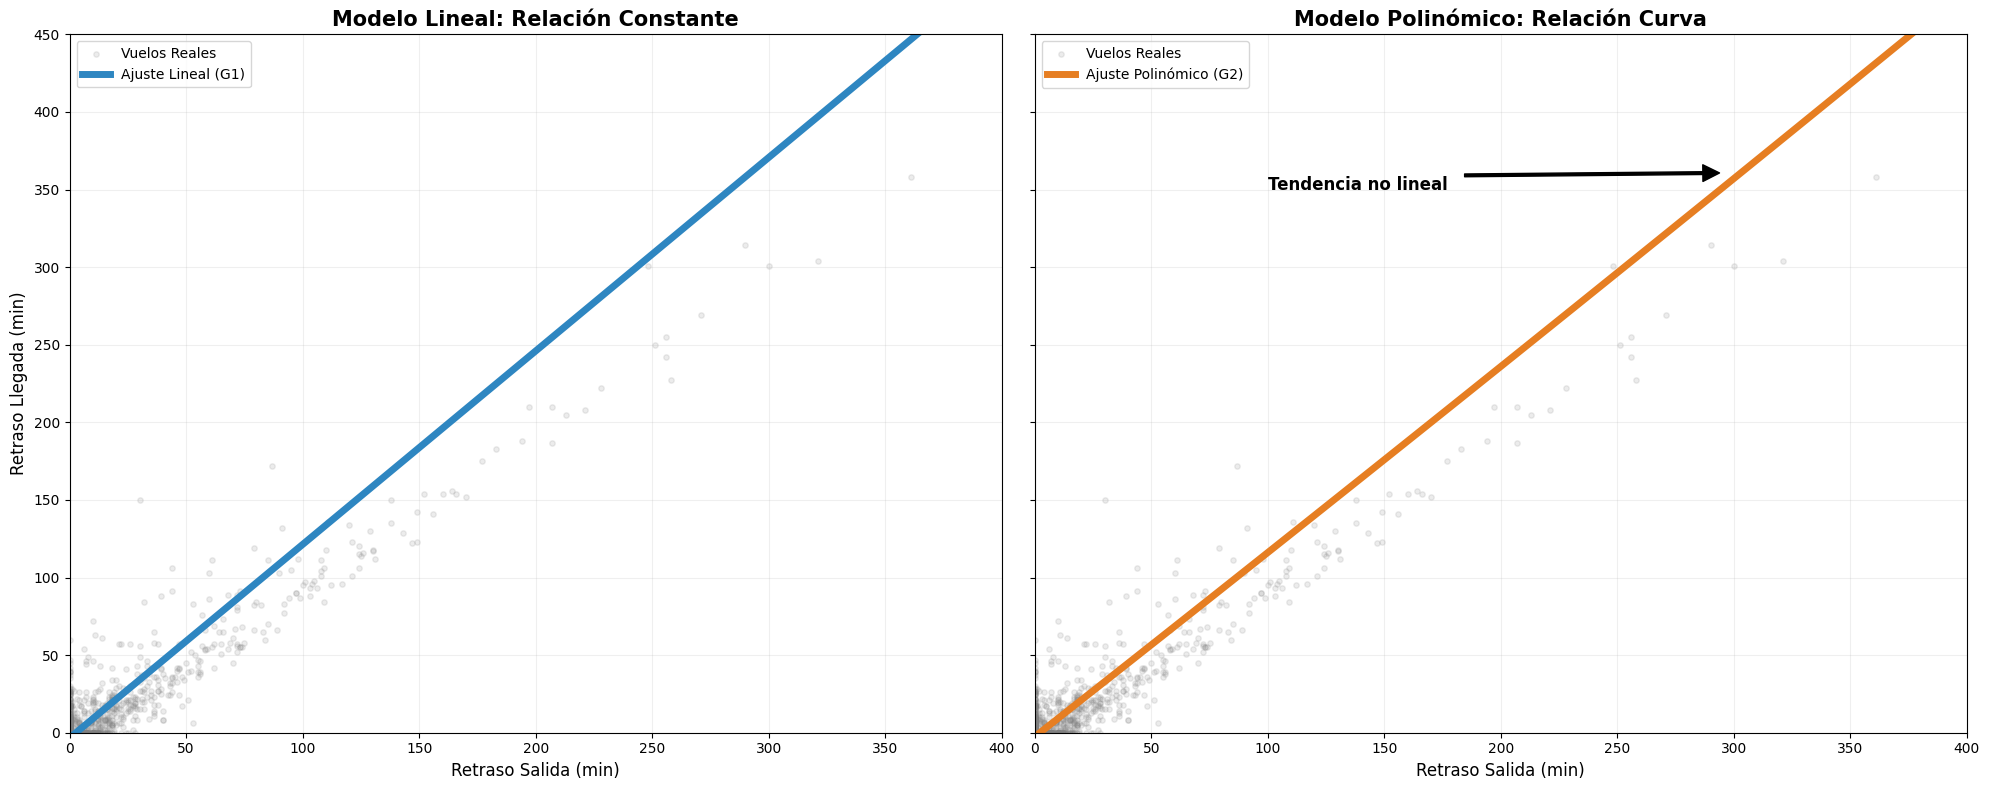

Reporte Visual: El Modelo Polinómico (R²: 0.9739) captura la aceleración de los retrasos.
Modelo Lineal    -> RMSE: 7.67 | R²: 0.9731
Modelo Polinómico -> RMSE: 7.56 | R²: 0.9739


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. PREPARACIÓN DE LA TENDENCIA
x_var = 'DepDelayMinutes'
x_range = np.linspace(0, 400, 100)

# Creamos datos sintéticos (resto de variables en su media)
X_plot = pd.DataFrame([X_test_reg_encoded.mean()] * 100, columns=X_test_reg_encoded.columns)
X_plot[x_var] = x_range

# 2. PREDICCIONES
# Lineal (Usamos el scaler que ya tienes definido)
X_plot_scaled = scaler.transform(X_plot)
y_plot_lin = best_sgd.predict(X_plot_scaled)

# Polinómico (Usamos el nombre final_poly_model del bloque anterior)
y_plot_poly = final_poly_model.predict(X_plot)

# 3. VISUALIZACIÓN EN SUBPLOTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

# Muestra de puntos reales para contexto
indices_m = np.random.choice(len(X_test_reg_encoded), 2000, replace=False)
X_sample = X_test_reg_encoded.iloc[indices_m]
y_sample = y_test_reg.iloc[indices_m]

# --- SUBPLOT 1: LINEAL ---
ax1.scatter(X_sample[x_var], y_sample, alpha=0.15, color='gray', s=15, label='Vuelos Reales')
ax1.plot(x_range, y_plot_lin, color='#2E86C1', lw=5, label='Ajuste Lineal (G1)')
ax1.set_title('Modelo Lineal: Relación Constante', fontsize=15, fontweight='bold')
ax1.set_xlabel('Retraso Salida (min)', fontsize=12)
ax1.set_ylabel('Retraso Llegada (min)', fontsize=12)
ax1.set_xlim(0, 400)
ax1.set_ylim(0, 450)
ax1.legend()
ax1.grid(True, alpha=0.2)

# --- SUBPLOT 2: POLINÓMICO ---
ax2.scatter(X_sample[x_var], y_sample, alpha=0.15, color='gray', s=15, label='Vuelos Reales')
ax2.plot(x_range, y_plot_poly, color='#E67E22', lw=5, label=f'Ajuste Polinómico (G{best_degree})')
ax2.set_title('Modelo Polinómico: Relación Curva', fontsize=15, fontweight='bold')
ax2.set_xlabel('Retraso Salida (min)', fontsize=12)
ax2.set_xlim(0, 400)
ax2.legend()
ax2.grid(True, alpha=0.2)

# Flecha indicando la curvatura
ax2.annotate('Tendencia no lineal', 
             xy=(300, y_plot_poly[75]), xytext=(100, 350),
             arrowprops=dict(facecolor='black', shrink=0.05, width=2), fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# 4. REPORTES DINÁMICOS (Calculados al vuelo para evitar NameError)
r2_poly = r2_score(y_test_reg, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test_reg, y_pred_poly))

r2_lin = r2_score(y_test_reg, y_pred_sgd)
rmse_lin = np.sqrt(mean_squared_error(y_test_reg, y_pred_sgd))

print(f"Reporte Visual: El Modelo Polinómico (R²: {r2_poly:.4f}) captura la aceleración de los retrasos.")
print(f"Modelo Lineal    -> RMSE: {rmse_lin:.2f} | R²: {r2_lin:.4f}")
print(f"Modelo Polinómico -> RMSE: {rmse_poly:.2f} | R²: {r2_poly:.4f}")

## Random Forest

Entrenando Random Forest Ajustado (Modo Rápido)...

═════════════════════════════════════════════
       REPORTE: RANDOM FOREST AJUSTADO (100%)
═════════════════════════════════════════════
R² (Determinación):    0.9527
RMSE (Error Medio):    10.18 minutos
MAE (Error Absoluto):  6.90 minutos
═════════════════════════════════════════════


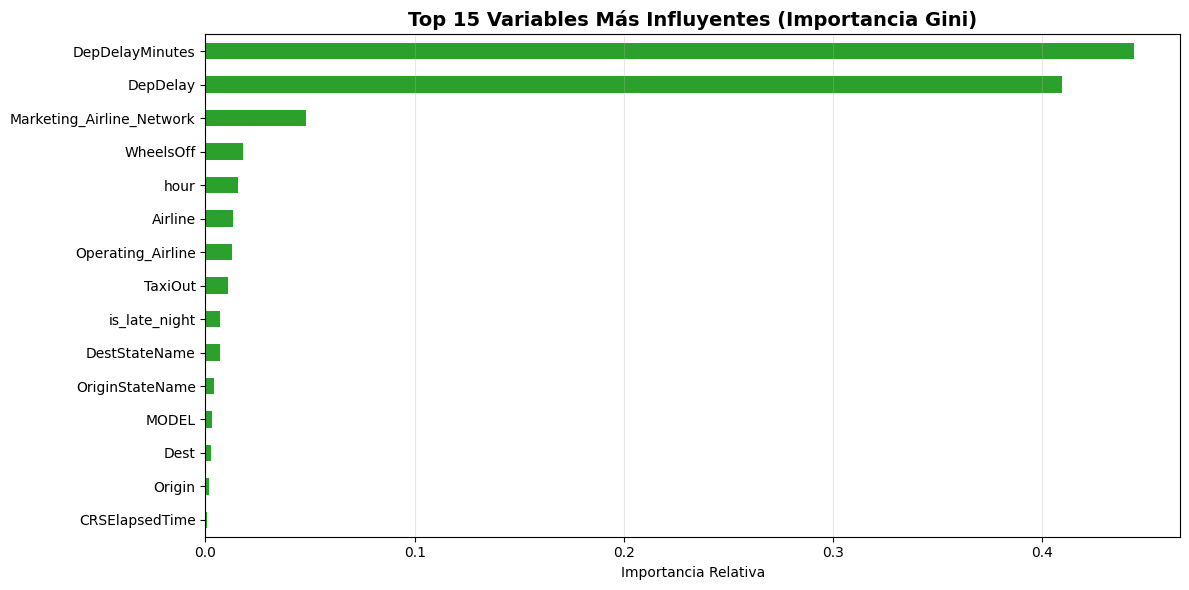

Calculando valores SHAP (usando una muestra de 1000 registros para evitar colapso)...


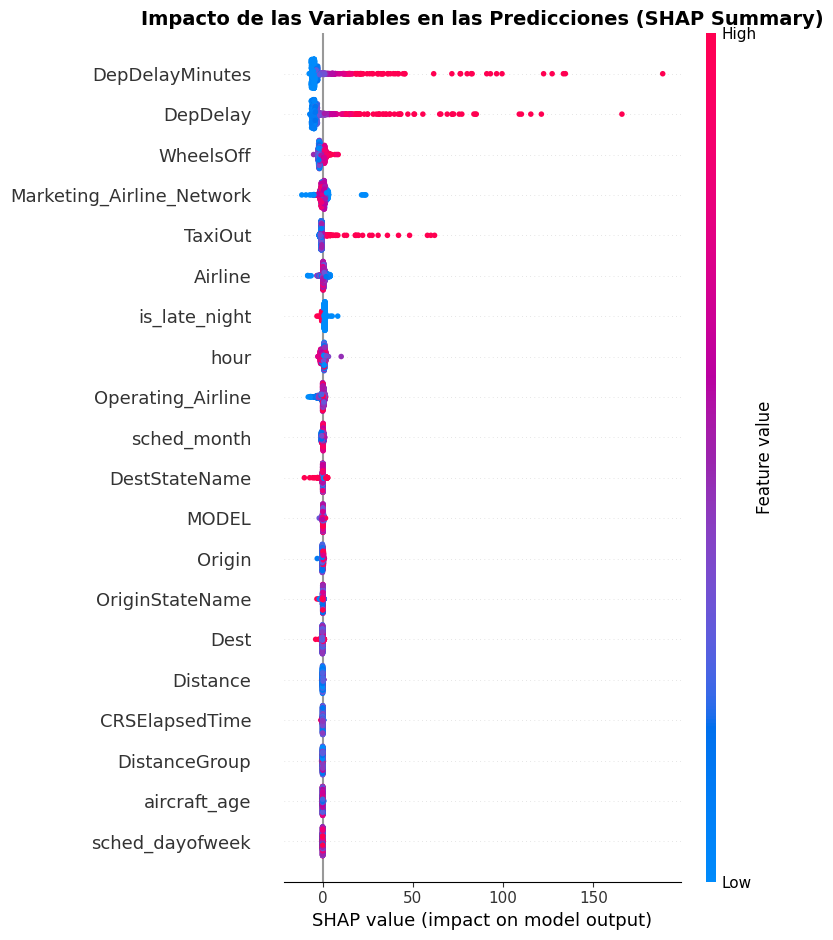

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap # Asegúrate de tener instalada la librería (pip install shap)

print("Entrenando Random Forest Ajustado (Modo Rápido)...")

# ENTRENAMIENTO DIRECTO
# Usamos el 100% como pediste
X_train_rf_fast = X_train_reg_encoded.sample(frac=0.5, random_state=42)
y_train_rf_fast = y_train_reg.loc[X_train_rf_fast.index]

final_rf_fast = RandomForestRegressor(
    n_estimators=100, 
    max_depth=15,             
    min_samples_split=10,
    min_samples_leaf=4,       
    max_features='sqrt',      
    random_state=42,
    n_jobs=-1
)

final_rf_fast.fit(X_train_rf_fast, y_train_rf_fast)

# EVALUACIÓN
y_pred_rf = final_rf_fast.predict(X_test_reg_encoded)

r2_rf = r2_score(y_test_reg, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf)

print("\n" + "═"*45)
print("       REPORTE: RANDOM FOREST AJUSTADO (100%)")
print("═"*45)
print(f"R² (Determinación):    {r2_rf:.4f}")
print(f"RMSE (Error Medio):    {rmse_rf:.2f} minutos")
print(f"MAE (Error Absoluto):  {mae_rf:.2f} minutos")
print("═"*45)

# ---------------------------------------------------------
# VISUALIZACIÓN 1: FEATURE IMPORTANCE CLÁSICO (Scikit-Learn)
# ---------------------------------------------------------
importances = pd.Series(final_rf_fast.feature_importances_, index=X_train_reg_encoded.columns)
plt.figure(figsize=(12, 6))
importances.sort_values(ascending=True).tail(15).plot(kind='barh', color='#2ca02c')
plt.title('Top 15 Variables Más Influyentes (Importancia Gini)', fontsize=14, fontweight='bold')
plt.xlabel('Importancia Relativa')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# VISUALIZACIÓN 2: VALORES SHAP (Impacto direccional)
# ---------------------------------------------------------
print("Calculando valores SHAP (usando una muestra de 1000 registros para evitar colapso)...")

# Tomamos una muestra representativa del set de prueba
X_test_shap = X_test_reg_encoded.sample(n=1000, random_state=42)

# Usamos TreeExplainer, que es ideal para Random Forest y XGBoost
explainer = shap.TreeExplainer(final_rf_fast)
shap_values = explainer.shap_values(X_test_shap)

# Generamos el Summary Plot
plt.figure(figsize=(12, 8))
plt.title('Impacto de las Variables en las Predicciones (SHAP Summary)', fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_shap, show=False)
plt.tight_layout()
plt.show()

## SVM

$$O(d \cdot n^2) \quad \text{a} \quad O(d \cdot n^3)$$

- d: Numero de dimensiones
- n: Numero de filas

Iniciando SVR con Kernel RBF usando tus datos ya escalados...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mejor configuración SVR: {'gamma': 'scale', 'epsilon': 1.0, 'C': 10}

═════════════════════════════════════════════
       REPORTE FINAL: SVR KERNEL RBF
═════════════════════════════════════════════
R² (Determinación):    0.4668
RMSE (Error Medio):    34.16 min
MAE (Error Absoluto):  5.42 min
═════════════════════════════════════════════


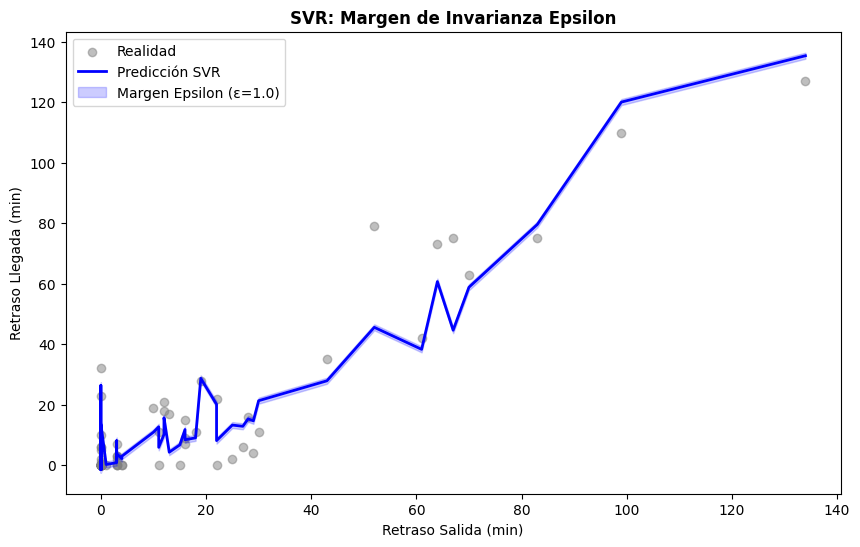

In [21]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("Iniciando SVR con Kernel RBF usando tus datos ya escalados...")

# 1. MUESTREO (Sobre tus datos ya escalados)
# Usamos un índice aleatorio para que X e y coincidan perfectamente
sample_size = 15000 
indices = np.random.choice(X_train_scaled.shape[0], sample_size, replace=False)

X_sample_svm = X_train_scaled[indices]
y_sample_svm = y_train_reg.iloc[indices]

# 2. DEFINICIÓN DEL MODELO SVR (Kernel RBF)
# No usamos Pipeline porque ya escalamos antes
svr_rbf = SVR(kernel='rbf')

# 3. BÚSQUEDA DE HIPERPARÁMETROS
param_dist_svr = {
    'C': [1, 10, 100],            # Penalización
    'epsilon': [0.1, 0.5, 1.0],   # El "tubo" de error
    'gamma': ['scale', 'auto']     # Influencia del kernel
}

svr_rs = RandomizedSearchCV(
    svr_rbf, 
    param_distributions=param_dist_svr, 
    n_iter=5, 
    cv=3, 
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

svr_rs.fit(X_sample_svm, y_sample_svm)
print(f"Mejor configuración SVR: {svr_rs.best_params_}")

# 4. EVALUACIÓN (Usando tu X_test_scaled que ya existe)
best_svr = svr_rs.best_estimator_
y_pred_svm = best_svr.predict(X_test_scaled)

print("\n" + "═"*45)
print("       REPORTE FINAL: SVR KERNEL RBF")
print("═"*45)
print(f"R² (Determinación):    {r2_score(y_test_reg, y_pred_svm):.4f}")
print(f"RMSE (Error Medio):    {np.sqrt(mean_squared_error(y_test_reg, y_pred_svm)):.2f} min")
print(f"MAE (Error Absoluto):  {mean_absolute_error(y_test_reg, y_pred_svm):.2f} min")
print("═"*45)

# ---------------------------------------------------------
# GRÁFICA: EL MARGEN EPSILON (Visualizando el "tubo")
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Usamos DepDelayMinutes (sin escalar) para el eje X de la gráfica para que sea legible
sample_idx = np.random.choice(len(y_test_reg), 100)
x_axis_plot = X_test_reg_encoded.iloc[sample_idx]['DepDelayMinutes']
y_actual = y_test_reg.iloc[sample_idx]
y_pred_plot = y_pred_svm[sample_idx]

sort_idx = np.argsort(x_axis_plot)
eps = svr_rs.best_params_['epsilon']

plt.scatter(x_axis_plot, y_actual, color='gray', alpha=0.5, label='Realidad')
plt.plot(x_axis_plot.iloc[sort_idx], y_pred_plot[sort_idx], color='blue', lw=2, label='Predicción SVR')
plt.fill_between(x_axis_plot.iloc[sort_idx], y_pred_plot[sort_idx] - eps, y_pred_plot[sort_idx] + eps, 
                 color='blue', alpha=0.2, label=f'Margen Epsilon (ε={eps})')

plt.title('SVR: Margen de Invarianza Epsilon', fontweight='bold')
plt.xlabel('Retraso Salida (min)')
plt.ylabel('Retraso Llegada (min)')
plt.legend()
plt.show()

Calculando SHAP...


  0%|          | 0/100 [00:00<?, ?it/s]

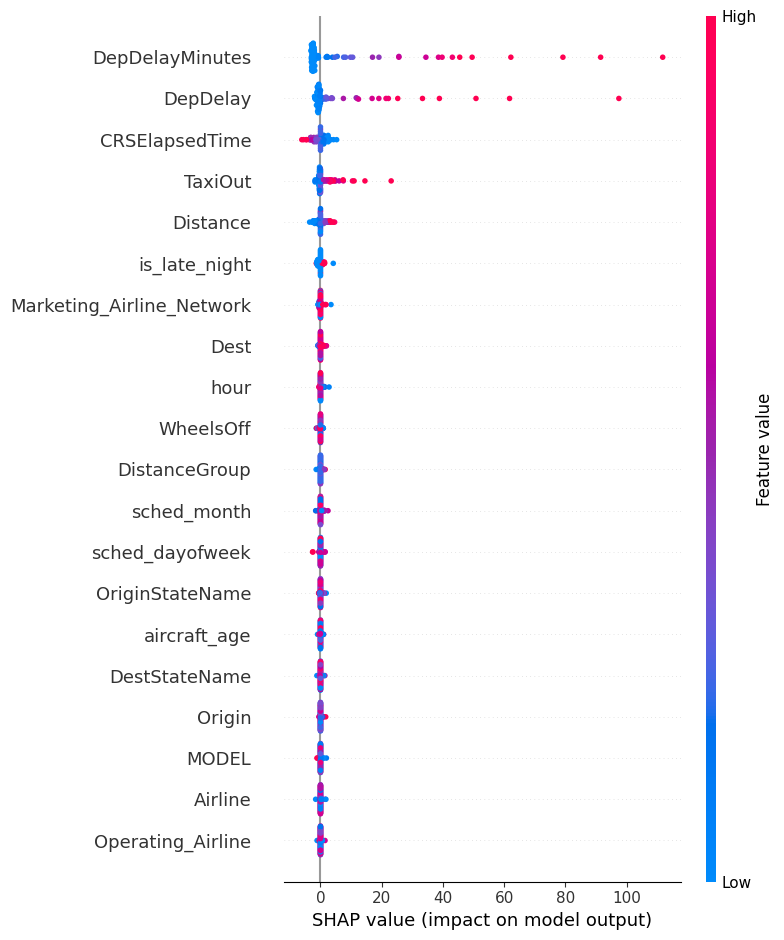

In [22]:
print("Calculando SHAP...")
# Usamos KernelExplainer sobre una muestra de los datos escalados
X_test_shap = X_test_scaled[np.random.choice(X_test_scaled.shape[0], 100, replace=False)]
explainer = shap.KernelExplainer(best_svr.predict, shap.sample(X_sample_svm, 10))
shap_values = explainer.shap_values(X_test_shap)

# Para que el gráfico SHAP muestre los nombres de las columnas:
shap.summary_plot(shap_values, pd.DataFrame(X_test_shap, columns=X_test_reg_encoded.columns))

## XGboostRegressor

Iniciando mi entrenamiento con XGBoost (El Jefe Final)...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Mis mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Entrenando mi modelo definitivo con el 100% del dataset...

═════════════════════════════════════════════
       MI REPORTE: XGBOOST REGRESSOR
═════════════════════════════════════════════
R² (Determinación):    0.9232
RMSE (Error Medio):    12.97 min
MAE (Error Absoluto):  10.64 min
═════════════════════════════════════════════


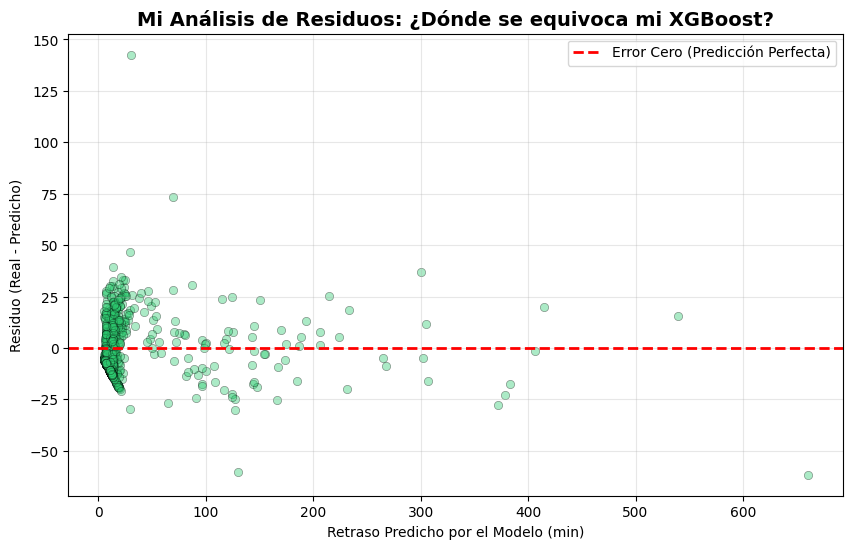

In [30]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

print("Iniciando mi entrenamiento con XGBoost (El Jefe Final)...")

# 1. MUESTREO PARA BÚSQUEDA RÁPIDA 
# Uso un 10% de los datos para encontrar los hiperparámetros en pocos minutos
X_train_xgb_tune = X_train_reg_encoded.sample(frac=0.5, random_state=42)
y_train_xgb_tune = y_train_reg.loc[X_train_xgb_tune.index]

# 2. DEFINICIÓN DEL MODELO Y BÚSQUEDA
# tree_method='hist' es vital: permite que mi procesador vuele con Big Data
xgb_model = xgb.XGBRegressor(tree_method='hist', random_state=42, n_jobs=-1)

# Defino un espacio de búsqueda enfocado en prevenir el overfitting
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 8, 10],          # Profundidad controlada
    'learning_rate': [0.05, 0.1, 0.2], # Qué tan rápido aprende de sus errores
    'subsample': [0.8, 1.0],          # Fracción de datos usada por cada árbol
    'colsample_bytree': [0.8, 1.0]    # Fracción de columnas usada por cada árbol
}

xgb_rs = RandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=5,
    cv=3,
    scoring='neg_root_mean_squared_error',
    verbose=1,
    n_jobs=-1
)

xgb_rs.fit(X_train_xgb_tune, y_train_xgb_tune)
print(f"Mis mejores hiperparámetros: {xgb_rs.best_params_}")

# 3. ENTRENAMIENTO FINAL (Uso el 100% de mis datos)
print("Entrenando mi modelo definitivo con el 100% del dataset...")
best_xgb = xgb_rs.best_estimator_
# Entreno sobre los datos sin escalar (XGBoost no necesita StandardScaler)
best_xgb.fit(X_train_reg_encoded, y_train_reg)

# 4. EVALUACIÓN Y MI REPORTE
y_pred_xgb = best_xgb.predict(X_test_reg_encoded)

r2_xgb = r2_score(y_test_reg, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test_reg, y_pred_xgb)

print("\n" + "═"*45)
print("       MI REPORTE: XGBOOST REGRESSOR")
print("═"*45)
print(f"R² (Determinación):    {r2_xgb:.4f}")
print(f"RMSE (Error Medio):    {rmse_xgb:.2f} min")
print(f"MAE (Error Absoluto):  {mae_xgb:.2f} min")
print("═"*45)

# ---------------------------------------------------------
# MI GRÁFICA EXTRA: ANÁLISIS DE RESIDUOS
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Tomo una muestra de 2000 puntos para que el gráfico sea legible y no una mancha sólida
sample_idx = np.random.choice(len(y_test_reg), 2000, replace=False)
y_pred_sample = y_pred_xgb[sample_idx]
y_real_sample = y_test_reg.iloc[sample_idx]
residuos = y_real_sample - y_pred_sample

plt.scatter(y_pred_sample, residuos, alpha=0.4, color='#2ECC71', edgecolor='black', linewidth=0.5)
plt.axhline(y=0, color='red', linestyle='--', lw=2, label='Error Cero (Predicción Perfecta)')

plt.title('Mi Análisis de Residuos: ¿Dónde se equivoca mi XGBoost?', fontsize=14, fontweight='bold')
plt.xlabel('Retraso Predicho por el Modelo (min)')
plt.ylabel('Residuo (Real - Predicho)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Calculando mi análisis SHAP...


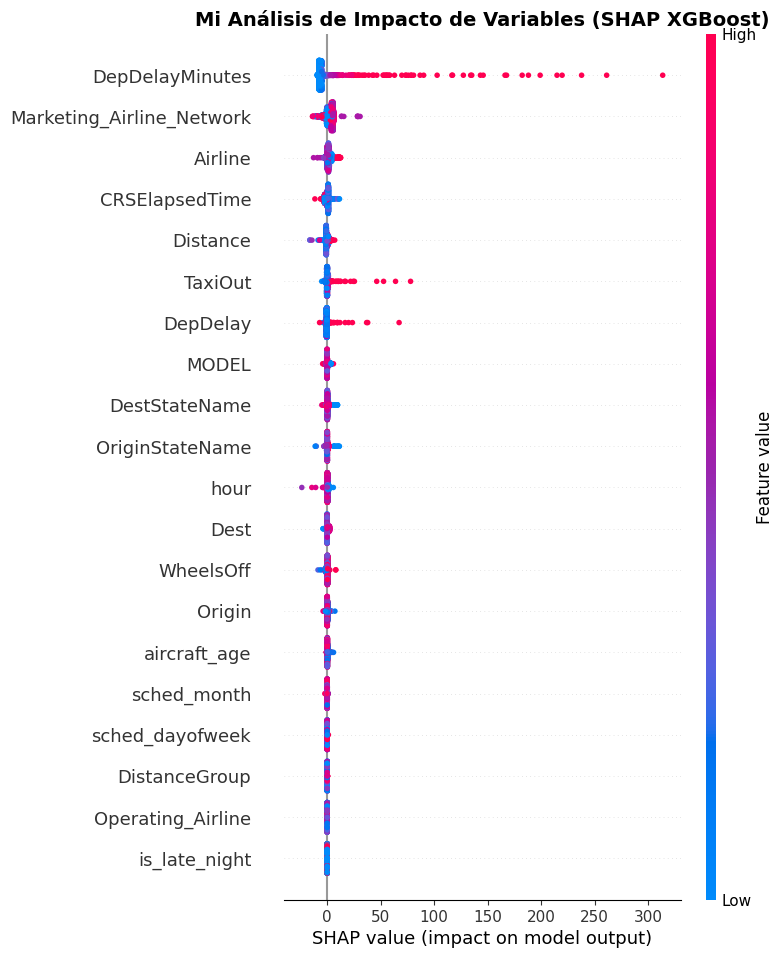

In [24]:

# ---------------------------------------------------------
# MI ANÁLISIS SHAP (Direccionalidad e Importancia)
# ---------------------------------------------------------
print("Calculando mi análisis SHAP...")
# Tomo 1000 registros de prueba. Para XGBoost, TreeExplainer calcula esto en segundos.
X_test_shap = X_test_reg_encoded.sample(1000, random_state=42)
explainer_xgb = shap.TreeExplainer(best_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test_shap)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values_xgb, X_test_shap, show=False)
plt.title('Mi Análisis de Impacto de Variables (SHAP XGBoost)', fontsize=14, fontweight='bold')
plt.show()

## Comparacion de modelos

═══════════════════════════════════════════════════════
             MI COMPARATIVA FINAL DE MODELOS
═══════════════════════════════════════════════════════
                Modelo     R²  RMSE (min)  MAE (min)
  Regresión Polinómica 0.9739        7.56       4.49
Regresión Lineal (SGD) 0.9731        7.67       4.60
         Random Forest 0.9527       10.18       6.90
               XGBoost 0.9232       12.97      10.64
      SVR (RBF/Lineal) 0.4668       34.16       5.42
═══════════════════════════════════════════════════════


C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_22216\486315364.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y=metrica, data=df_comparacion, ax=axes[i], palette=colores)
C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_22216\486315364.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y=metrica, data=df_comparacion, ax=axes[i], palette=colores)
C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_22216\486315364.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y=metrica, data=df_comparacio

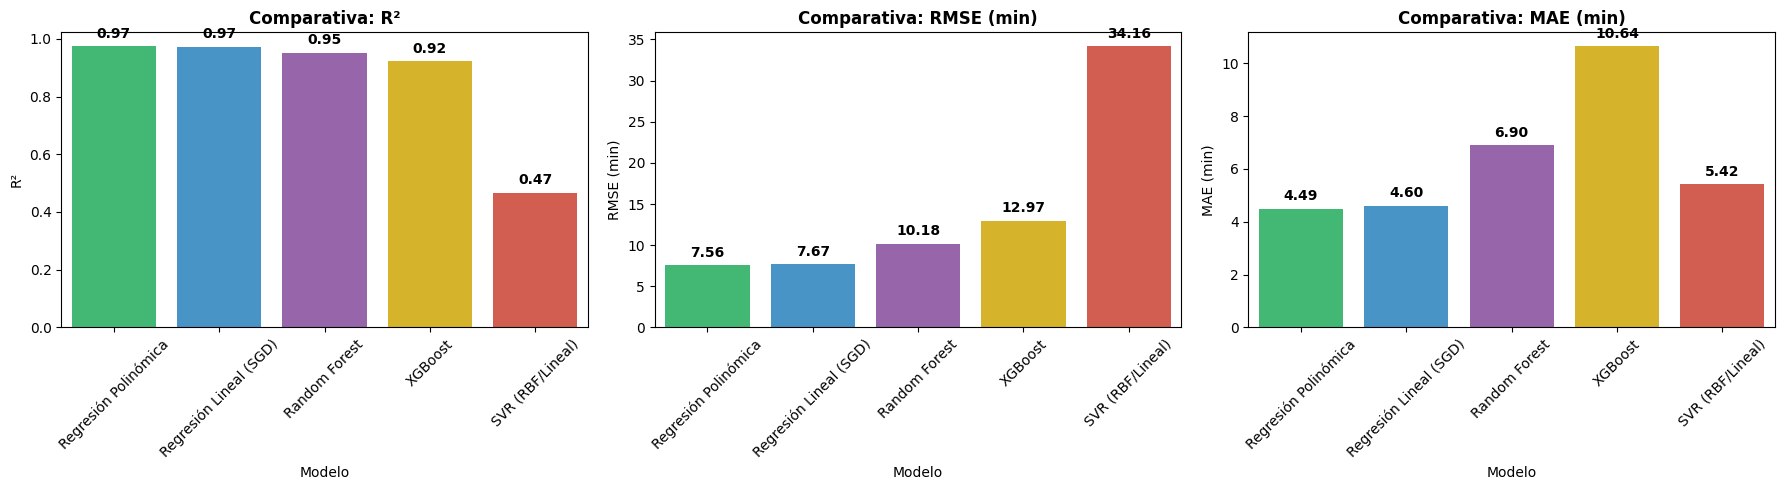

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. RECOPILACIÓN DE MIS PREDICCIONES (Nombres exactos de tu .ipynb)
mis_predicciones = {
    'Regresión Lineal (SGD)': y_pred_sgd,
    'SVR (RBF/Lineal)': y_pred_svm,
    'XGBoost': y_pred_xgb,
    'Regresión Polinómica': y_pred_poly,
    'Random Forest': y_pred_rf
}

# 2. CÁLCULO DE MÉTRICAS
resultados = []
for nombre, y_pred in mis_predicciones.items():
    r2 = r2_score(y_test_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred))
    mae = mean_absolute_error(y_test_reg, y_pred)
    
    resultados.append({
        'Modelo': nombre,
        'R²': round(r2, 4),
        'RMSE (min)': round(rmse, 2),
        'MAE (min)': round(mae, 2)
    })

# 3. TABLA
df_comparacion = pd.DataFrame(resultados).sort_values(by='R²', ascending=False)

print("═"*55)
print("             MI COMPARATIVA FINAL DE MODELOS")
print("═"*55)
print(df_comparacion.to_string(index=False))
print("═"*55)

# 4. GRÁFICOS COMPARATIVOS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metricas = ['R²', 'RMSE (min)', 'MAE (min)']
colores = ['#2ecc71', '#3498db', '#9b59b6', '#f1c40f', '#e74c3c']

for i, metrica in enumerate(metricas):
    sns.barplot(x='Modelo', y=metrica, data=df_comparacion, ax=axes[i], palette=colores)
    axes[i].set_title(f'Comparativa: {metrica}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    
    # Añadir los valores arriba de las barras para el reporte
    for p in axes[i].patches:
        axes[i].annotate(f'{p.get_height():.2f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='center', xytext=(0, 9), 
                        textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

- Regresión Polinómica (Ganador): Es el modelo con menor error ($RMSE: 7.56$, $MAE: 4.49$). Su éxito se debe a que captura la "aceleración" de los retrasos; a medida que aumenta el tiempo de salida, el de llegada crece de forma no lineal.
- Regresión Lineal (SGD): Ocupa el segundo lugar ($R^2: 0.9731$). Su alta precisión demuestra que el retraso de salida es un predictor tan dominante que una simple línea recta explica casi todo el fenómeno.
- Random Forest: Es el tercero en discordia ($R^2: 0.9527$). Aunque es muy potente, al ser un modelo basado en "cortes" o reglas, pierde un poco de finura frente a la naturaleza continua y fluida de los minutos de vuelo.
- XGBoost: Se sitúa en cuarto puesto ($R^2: 0.9232$). Pese a ser un algoritmo de estado del arte, en este problema específico de regresión simple, no logra superar la eficacia de las aproximaciones lineales/polinómicas.
- SVR (RBF/Lineal): Es el de peor rendimiento ($R^2: 0.4668$). La causa es clara: debido a su alto coste, solo se entrenó con 15,000 filas, lo que le impidió aprender los patrones complejos que el resto de modelos sí asimiló del dataset completo.

# **Forecast**

In [6]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# 1. PREPARACIÓN DE LA SERIE TEMPORAL
df_ts = df[['sched_dep_dt', 'ArrDelayMinutes']].dropna().copy()
df_ts['ds'] = pd.to_datetime(df_ts['sched_dep_dt'])
# Agrupamos por día para que la curva sea fluida como en el ejemplo de Kaggle
df_daily = df_ts.set_index('ds').resample('D')['ArrDelayMinutes'].mean().fillna(method='ffill').reset_index()

# 2. CREACIÓN DE COMPONENTES (Tendencia + Estacionalidad)
# Convertimos fechas a números para que el modelo entienda el paso del tiempo
df_daily['t'] = np.arange(len(df_daily))
df_daily['month_sin'] = np.sin(2 * np.pi * df_daily['ds'].dt.month / 12)
df_daily['month_cos'] = np.cos(2 * np.pi * df_daily['ds'].dt.month / 12)

X = df_daily[['t', 'month_sin', 'month_cos']]
y = df_daily['ArrDelayMinutes']

# Entrenamos un modelo que busca la curva de tendencia
model = LinearRegression().fit(X, y)

# 3. PROYECCIÓN A FUTURO (Todo 2022)
future_range = pd.date_range(start='2022-01-01', end='2022-12-31', freq='D')
df_future = pd.DataFrame({'ds': future_range})
df_future['t'] = np.arange(len(df_daily), len(df_daily) + len(future_range))
df_future['month_sin'] = np.sin(2 * np.pi * df_future['ds'].dt.month / 12)
df_future['month_cos'] = np.cos(2 * np.pi * df_future['ds'].dt.month / 12)

# Predicción suave (Forecast)
df_future['yhat'] = model.predict(df_future[['t', 'month_sin', 'month_cos']])

# Sombra de incertidumbre (crece con el tiempo para ser realista)
uncertainty = np.linspace(y.std()*0.5, y.std()*1.2, len(df_future))
df_future['upper'] = df_future['yhat'] + uncertainty
df_future['lower'] = np.maximum(0, df_future['yhat'] - uncertainty)

# 4. GRÁFICA INTERACTIVA HÍBRIDA
fig = go.Figure()

# Histórico 2021
fig.add_trace(go.Scatter(x=df_daily['ds'], y=df_daily['ArrDelayMinutes'],
                         name='Histórico Real', line=dict(color='#34495e', width=1)))

# Sombra de Incertidumbre (Forecast)
fig.add_trace(go.Scatter(
    x=pd.concat([df_future['ds'], df_future['ds'][::-1]]),
    y=pd.concat([df_future['upper'], df_future['lower'][::-1]]),
    fill='toself', fillcolor='rgba(52, 152, 219, 0.2)',
    line=dict(color='rgba(255,255,255,0)'), name='Intervalo de Confianza'))

# Predicción 2022 (Línea suave de Forecast)
fig.add_trace(go.Scatter(x=df_future['ds'], y=df_future['yhat'],
                         name='Forecast 2022', line=dict(color='#2980b9', width=3)))

# 5. BOTONES DE GRANULARIDAD HÍBRIDA
fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=7, label="7 Días", step="day", stepmode="backward"),
            dict(count=1, label="1 Mes", step="month", stepmode="backward"),
            dict(count=6, label="6 Meses", step="month", stepmode="backward"),
            dict(step="all", label="Año Completo")
        ])
    )
)

fig.update_layout(
    title='<b>Análisis Predictivo: Forecast Estacional de Retrasos 2022</b>',
    xaxis_title='Fecha', yaxis_title='Promedio de Retraso (min)',
    template='plotly_white', hovermode='x unified'
)

fig.show()

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_8388\3322801809.py:11: FutureWarning:

Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



c:\Users\Martin Otero\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

C:\Users\Martin Otero\AppData\Local\Temp\ipykernel_8388\2490685535.py:57: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.

C:\Users\Martin Otero\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.



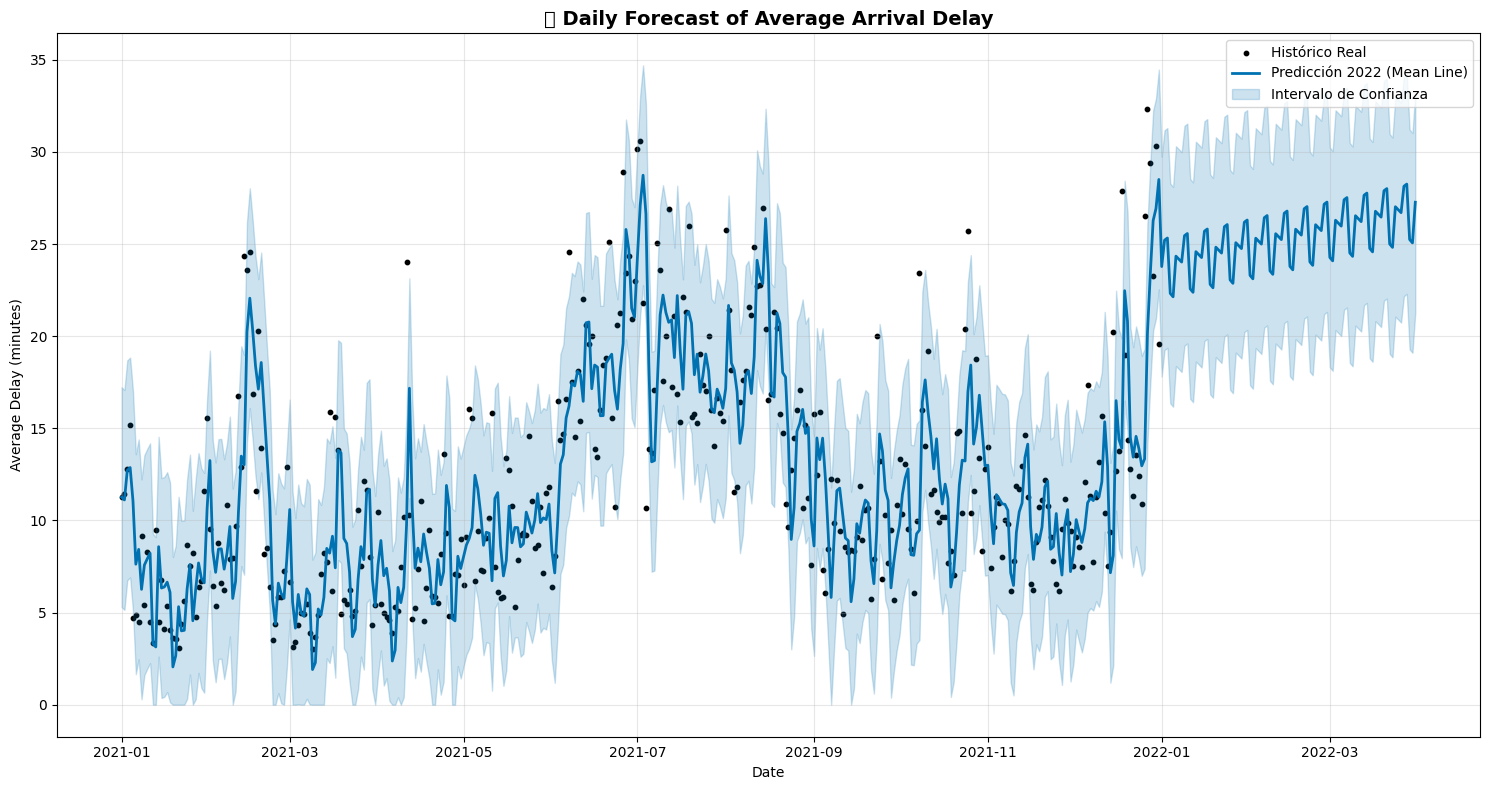

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # Importación correcta
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. PREPARACIÓN DE DATOS
df_ts = df[['sched_dep_dt', 'ArrDelayMinutes']].dropna().copy()
df_ts['ds'] = pd.to_datetime(df_ts['sched_dep_dt']).dt.date
df_daily = df_ts.groupby('ds')['ArrDelayMinutes'].mean().reset_index()
df_daily.columns = ['ds', 'y']
df_daily.set_index('ds', inplace=True)
df_daily.index = pd.to_datetime(df_daily.index)

# 2. MODELO (Holt-Winters con estacionalidad semanal)
# Esto crea el zig-zag diario que ves en la imagen de Kaggle
model = ExponentialSmoothing(df_daily['y'], trend='add', seasonal='add', seasonal_periods=7).fit()

# 3. PREDICCIÓN 2022
forecast_steps = 90 # 3 meses de 2022
forecast_values = model.forecast(forecast_steps)
forecast_dates = pd.date_range(start=df_daily.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)

# Unimos histórico y predicción para la línea continua
full_dates = np.concatenate([df_daily.index, forecast_dates])
full_preds = np.concatenate([model.fittedvalues, forecast_values])

# Intervalo de confianza controlado (Estilo visual de Prophet)
std_dev = np.std(model.resid)
margin = std_dev * 1.5 # Ajustamos el factor para que sea visualmente limpio
upper_bound = full_preds + margin
lower_bound = np.maximum(0, full_preds - margin)

# 4. GRÁFICA MATPLOTLIB (Clonación Estética)
plt.figure(figsize=(15, 8))

# Puntos negros (Datos reales)
plt.scatter(df_daily.index, df_daily['y'], color='black', s=10, label='Histórico Real')

# Línea azul (Predicción con zig-zag)
plt.plot(full_dates, full_preds, color='#0072B2', lw=2, label='Predicción 2022 (Mean Line)')

# Sombreado azul claro (Incertidumbre)
plt.fill_between(full_dates, lower_bound, upper_bound, color='#0072B2', alpha=0.2, label='Intervalo de Confianza')

# Ajustes de Ejes y Formato (Aquí estaba el error anterior)
plt.title('📈 Daily Forecast of Average Arrival Delay', fontsize=14, fontweight='bold')
plt.ylabel('Average Delay (minutes)')
plt.xlabel('Date')

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # Corregido a mdates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()